# Proyecto 2 - Modelado Predictivo de Mortalidad

Este notebook implementa el flujo completo de modelado supervisado. Mantiene separado el Proyecto 1 (EDA/Clustering) del Proyecto 2 (Modelos).

**Fases:**
- Fase 0: Reutilización controlada de limpieza
- Fase 1: Definición de variable objetivo (`grupo_causa_cie10`, 34 clases)
- Fase 3: Preparación de datos (features, limpieza, feature engineering)
- Fase 4: Train / Validation / Test split (70 / 15 / 15 %, estratificado)
- Fase 5: Selección de algoritmos (Reg. Logística, Random Forest, ExtraTrees, CatBoost)
- Fase 6: Preprocesamiento y pipeline (ColumnTransformer)
- Modelo 1: Regresión Logística (baseline)
- Modelo 2: Random Forest — barrido de 3 versiones + modelo final
- Modelo 3: ExtraTreesClassifier
- Modelo 4: CatBoostClassifier
- Fase 7: Resultados, matriz de confusión e importancia de variables

## Fase 0 - Reutilizacion controlada

Este notebook reutiliza logica de limpieza ya alineada con el Proyecto 1 (ejemplo: tratamiento de `Edadif == 999` y manejo de columnas entre anos).

Se mantiene separado de `main.ipynb` para:
- evitar notebooks demasiado largos,
- no afectar el flujo EDA/Clustering,
- facilitar revision independiente en GitHub y por el profesor.


In [2]:
from __future__ import annotations

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import pyreadstat

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostClassifier

In [3]:
RANDOM_STATE = 42
YEARS = list(range(2013, 2023))
DATA_DIR = Path('data/defunciones')

# Opcional para prototipar rapido en equipos con menos RAM
USE_SAMPLE = False
SAMPLE_SIZE = 200_000

np.random.seed(RANDOM_STATE)

In [4]:
def normalize_text(value: str) -> str:
    if value is None:
        return ''
    value = unicodedata.normalize('NFKD', str(value))
    value = ''.join(ch for ch in value if not unicodedata.combining(ch))
    return value.lower().strip()


def resolve_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    norm_map = {normalize_text(col): col for col in df.columns}
    for candidate in candidates:
        key = normalize_text(candidate)
        if key in norm_map:
            return norm_map[key]
    return None


def normalize_cie10(code: object) -> str | None:
    if pd.isna(code):
        return None
    text = str(code).upper().strip()
    # Captura codigos tipo A15, I21, Y87.0
    match = re.search(r'[A-Z][0-9]{2}(?:\.[0-9])?', text)
    return match.group(0) if match else None


def _cie_num(cie10: str) -> int | None:
    try:
        return int(cie10[1:3])
    except Exception:
        return None


def map_causa_grupo(cie10: str | None) -> str | None:
    """
    Mapeo detallado inspirado en diccionario.md, con clases no traslapadas
    para clasificacion supervisada.
    """
    if cie10 is None:
        return None

    letter = cie10[0]
    num = _cie_num(cie10)

    # Infecciosas
    if letter in {'A', 'B'}:
        return 'Infecciosas'

    # Neoplasias / sangre e inmunidad
    if letter == 'C':
        return 'Neoplasias'
    if letter == 'D' and num is not None:
        if 0 <= num <= 48:
            return 'Neoplasias'
        if 50 <= num <= 89:
            return 'Sangre_inmunidad'

    # Endocrinas, mentales, nervioso/sentidos
    if letter == 'E':
        return 'Endocrinas_metabolicas'
    if letter == 'F':
        return 'Trastornos_mentales'
    if letter in {'G', 'H'}:
        return 'Nervioso_organos_sentidos'

    # Circulatorias (subgrupos del diccionario)
    if letter == 'I' and num is not None:
        if 10 <= num <= 13:
            return 'Hipertensiva'
        if 20 <= num <= 25:
            return 'Isquemica_corazon'
        if 60 <= num <= 69:
            return 'Cerebrovascular'
        return 'Otras_circulatorias'

    # Respiratorias (subgrupos del diccionario)
    if letter == 'J' and num is not None:
        if 10 <= num <= 18:
            return 'Neumonia_influenza'
        if 40 <= num <= 47:
            return 'EPOC'
        return 'Otras_respiratorias'

    # Digestivas (subgrupos del diccionario)
    if letter == 'K' and num is not None:
        if num == 70 or 73 <= num <= 74:
            return 'Cronica_higado'
        if 35 <= num <= 38:
            return 'Apendicitis'
        if (40 <= num <= 46) or num == 56:
            return 'Hernia_obstruccion_intestinal'
        return 'Otras_digestivas'

    # Genitourinarias (subgrupos del diccionario)
    if letter == 'N' and num is not None:
        if (0 <= num <= 7) or (17 <= num <= 19) or (25 <= num <= 27):
            return 'Nefritis_sindrome_nefrotico'
        return 'Otras_genitourinarias'

    # Causas externas (subgrupos del diccionario)
    if letter == 'V' and num is not None:
        if 2 <= num <= 89:
            return 'Accidentes_transito'
        return 'Accidentes_no_intencionales'

    if letter == 'W':
        return 'Accidentes_no_intencionales'

    if letter == 'X' and num is not None:
        if 60 <= num <= 84:
            return 'Suicidio'
        if 85 <= num <= 99:
            return 'Homicidio'
        return 'Accidentes_no_intencionales'

    if letter == 'Y' and num is not None:
        if 0 <= num <= 9:
            return 'Homicidio'
        if 40 <= num <= 59:
            return 'Efectos_adversos_medicamentos'
        if 85 <= num <= 86:
            return 'Accidentes_no_intencionales'
        return 'Otras_causas_externas'

    # Separaciones clave para no perder informacion
    if letter == 'R' and num is not None:
        if num == 98:
            return 'Muerte_sin_asistencia_R98'
        if num == 99:
            return 'Causa_mal_definida_R99'
        if num == 54:
            return 'Senilidad_R54'
        return 'Sintomas_signos_hallazgos'
    if letter == 'Q':
        return 'Congenitas'
    if letter == 'P':
        return 'Perinatales'
    if letter == 'O':
        return 'Embarazo_parto_puerperio'
    if letter == 'U':
        return 'Codigos_especiales'

    # Otros capitulos CIE-10
    if letter in {'L', 'M', 'Z'}:
        return 'Otros_capitulos'

    return 'Otros_capitulos'


def load_yearly_data(data_dir: Path, years: list[int]) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for year in years:
        path = data_dir / f'{year}.sav'
        if not path.exists():
            print(f'[WARN] No existe: {path}')
            continue
        df_year, _ = pyreadstat.read_sav(str(path))
        df_year['__year_file__'] = year
        frames.append(df_year)
        print(f'[OK] {year}: {len(df_year):,} registros')

    if not frames:
        raise FileNotFoundError('No se pudieron cargar archivos .sav en data/defunciones')

    return pd.concat(frames, ignore_index=True)


In [5]:
df = load_yearly_data(DATA_DIR, YEARS)
print(f'\nShape consolidado: {df.shape}')

if USE_SAMPLE and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'Se usa muestra para prototipado: {df.shape}')

[OK] 2013: 76,639 registros
[OK] 2014: 77,807 registros
[OK] 2015: 80,876 registros
[OK] 2016: 82,565 registros
[OK] 2017: 81,726 registros
[OK] 2018: 83,071 registros
[OK] 2019: 85,600 registros
[OK] 2020: 96,001 registros
[OK] 2021: 118,465 registros
[OK] 2022: 95,386 registros

Shape consolidado: (878136, 30)


## Fase 1 - Variable objetivo

**Variable respuesta seleccionada:** `grupo_causa_cie10` (derivada de `Caudef` CIE-10).

- Tipo: **cualitativa nominal** (clasificacion multiclase).
- Enfoque: mapeo **detallado** inspirado en `diccionario.md`, no consolidado.
- Clases principales consideradas:
  - `Infecciosas`, `Neoplasias`, `Sangre_inmunidad`, `Endocrinas_metabolicas`, `Trastornos_mentales`, `Nervioso_organos_sentidos`
  - `Hipertensiva`, `Isquemica_corazon`, `Cerebrovascular`, `Otras_circulatorias`
  - `Neumonia_influenza`, `EPOC`, `Otras_respiratorias`
  - `Cronica_higado`, `Apendicitis`, `Hernia_obstruccion_intestinal`, `Otras_digestivas`
  - `Nefritis_sindrome_nefrotico`, `Otras_genitourinarias`
  - `Accidentes_transito`, `Accidentes_no_intencionales`, `Suicidio`, `Homicidio`, `Efectos_adversos_medicamentos`, `Otras_causas_externas`
  - `Muerte_sin_asistencia_R98`, `Causa_mal_definida_R99`, `Senilidad_R54`, `Sintomas_signos_hallazgos`
  - `Congenitas`, `Perinatales`, `Embarazo_parto_puerperio`, `Codigos_especiales`, `Otros_capitulos`

Fuente: `diccionario.md` (tabla CIE-10) y estructura de capitulos ICD-10 OMS.

Nota metodologica: las clases R pueden sugerir problemas de calidad de certificacion o diagnostico, pero no prueban por si solas negligencia medica.


In [6]:
caudef_col = resolve_column(df, ['Caudef'])
if caudef_col is None:
    raise KeyError('No se encontro la columna Caudef para construir la variable objetivo.')

df['cie10_norm'] = df[caudef_col].apply(normalize_cie10)
df['grupo_causa_cie10'] = df['cie10_norm'].apply(map_causa_grupo)

print('Distribucion inicial de la variable objetivo:')
display(df['grupo_causa_cie10'].value_counts(dropna=False).to_frame('conteo'))

df = df[df['grupo_causa_cie10'].notna()].copy()
print(f'\nRegistros tras remover objetivo nulo: {len(df):,}')

Distribucion inicial de la variable objetivo:


,conteo
grupo_causa_cie10,
Endocrinas_metabolicas,91789
Neoplasias,84843
Isquemica_corazon,68284
Neumonia_influenza,62336
Accidentes_no_intencionales,60300
Infecciosas,41420
Muerte_sin_asistencia_R98,34582
Homicidio,34397
Cronica_higado,34237



Registros tras remover objetivo nulo: 878,136


## Diagnostico de clases R y `Otros_capitulos`

Se analiza por separado `R98`, `R99` y `R54`, dejando `Sintomas_signos_hallazgos` para el resto de codigos R.


In [7]:
def resumen_clase(clase: str) -> None:
    mask = df['grupo_causa_cie10'].eq(clase)
    df_sub = df.loc[mask, ['cie10_norm', caudef_col, '__year_file__']].copy()

    print(f'=== {clase} ===')
    if df_sub.empty:
        print('Sin registros.')
        return

    total = len(df)
    n = len(df_sub)
    print(f'Registros: {n:,} ({n / total:.2%} del total)')

    df_sub['cie10_letra'] = df_sub['cie10_norm'].str[0]

    print()
    print('Top 12 codigos CIE-10:')
    display(df_sub['cie10_norm'].value_counts().head(12).to_frame('conteo'))

    print()
    print('Distribucion por letra CIE-10:')
    display(df_sub['cie10_letra'].value_counts().to_frame('conteo'))

clases_r = [
    'Muerte_sin_asistencia_R98',
    'Causa_mal_definida_R99',
    'Senilidad_R54',
    'Sintomas_signos_hallazgos',
    'Otros_capitulos',
]

for c in clases_r:
    resumen_clase(c)
    print()


=== Muerte_sin_asistencia_R98 ===
Registros: 34,582 (3.94% del total)

Top 12 codigos CIE-10:


,conteo
cie10_norm,
R98,34582



Distribucion por letra CIE-10:


,conteo
cie10_letra,
R,34582



=== Causa_mal_definida_R99 ===
Registros: 27,258 (3.10% del total)

Top 12 codigos CIE-10:


...

,conteo
cie10_letra,
R,17715



=== Otros_capitulos ===
Registros: 5,010 (0.57% del total)

Top 12 codigos CIE-10:


,conteo
cie10_norm,
M06,763
L98,618
M32,548
L89,354
M13,327
M19,323
M81,282
L08,243
M79,185



Distribucion por letra CIE-10:


,conteo
cie10_letra,
M,3352
L,1658


## Interpretacion de clases R (detalle)

Se separaron los codigos dominantes de R para no ocultar informacion:
- `R98`: muerte sin asistencia
- `R99`: causa mal definida/no especificada
- `R54`: senilidad
- `Sintomas_signos_hallazgos`: resto de codigos R

Lectura epidemiologica sugerida:
- Un volumen alto de estas clases puede reflejar limites de certificacion, registro o acceso diagnostico.
- No implica por si solo negligencia medica, pero si una señal fuerte de calidad del dato.


In [8]:
R_DESCRIPTIONS = {
    'R98': 'Muerte sin asistencia (unattended death)',
    'R99': 'Otras causas mal definidas o no especificadas de mortalidad',
    'R54': 'Senilidad',
    'R68': 'Otros sintomas y signos generales',
    'R50': 'Fiebre de origen desconocido',
    'R57': 'Choque (shock), no clasificado en otra parte',
    'R09': 'Otros sintomas del sistema circulatorio y respiratorio',
}

# Analiza solo el R residual (ya sin R98, R99, R54)
df_r_residual = df[df['grupo_causa_cie10'] == 'Sintomas_signos_hallazgos'].copy()

if df_r_residual.empty:
    print('No hay registros en Sintomas_signos_hallazgos residual.')
else:
    top_r = (
        df_r_residual['cie10_norm']
        .value_counts()
        .head(12)
        .rename_axis('codigo_r')
        .reset_index(name='conteo')
    )
    top_r['descripcion'] = top_r['codigo_r'].map(R_DESCRIPTIONS).fillna('Descripcion CIE-10 no cargada en este resumen')
    top_r['porcentaje_dentro_R_residual'] = (top_r['conteo'] / len(df_r_residual) * 100).round(2)

    print(f'Registros totales en R residual: {len(df_r_residual):,}')
    print('Top codigos R residuales y su interpretacion:')
    display(top_r[['codigo_r', 'conteo', 'porcentaje_dentro_R_residual', 'descripcion']])

# Resumen de los 4 grupos R
resumen_r = df['grupo_causa_cie10'].value_counts().reindex([
    'Muerte_sin_asistencia_R98',
    'Causa_mal_definida_R99',
    'Senilidad_R54',
    'Sintomas_signos_hallazgos',
]).fillna(0).astype(int).to_frame('conteo')

resumen_r['porcentaje_total'] = (resumen_r['conteo'] / len(df) * 100).round(2)
print()
print('Resumen de desagregacion de R:')
display(resumen_r)


Registros totales en R residual: 17,715
Top codigos R residuales y su interpretacion:


,codigo_r,conteo,porcentaje_dentro_R_residual,descripcion
0,R68,2688,15.17,Otros sintomas y signos generales
1,R50,2589,14.61,Fiebre de origen desconocido
2,R57,2393,13.51,"Choque (shock), no clasificado en otra parte"
3,R09,2358,13.31,Otros sintomas del sistema circulatorio y resp...
4,R95,1684,9.51,Descripcion CIE-10 no cargada en este resumen
5,R56,1666,9.40,Descripcion CIE-10 no cargada en este resumen
6,R10,1299,7.33,Descripcion CIE-10 no cargada en este resumen
7,R96,747,4.22,Descripcion CIE-10 no cargada en este resumen
8,R05,557,3.14,Descripcion CIE-10 no cargada en este resumen
9,R11,179,1.01,Descripcion CIE-10 no cargada en este resumen



Resumen de desagregacion de R:


,conteo,porcentaje_total
grupo_causa_cie10,,
Muerte_sin_asistencia_R98,34582,3.94
Causa_mal_definida_R99,27258,3.10
Senilidad_R54,23587,2.69
Sintomas_signos_hallazgos,17715,2.02


## Fase 3 - Preparacion de datos

En esta fase se construye una matriz de modelado sin fuga de informacion:
- no se usa `Caudef` como feature (origen directo de la etiqueta),
- se limpian sentinelas (`Edadif == 999`),
- se generan variables temporales simples para mejorar senal predictiva.


In [9]:
sexo_col = resolve_column(df, ['Sexo'])
edad_col = resolve_column(df, ['Edadif'])
depocu_col = resolve_column(df, ['Depocu', 'Depreg'])
mupocu_col = resolve_column(df, ['Mupocu', 'Mupreg'])
mes_col = resolve_column(df, ['Mesocu', 'Mesreg'])
dia_col = resolve_column(df, ['Diaocu'])
anio_col = resolve_column(df, ['Añoocu', 'Anoocu', 'Añoreg', 'Anoreg'])
ecivil_col = resolve_column(df, ['Ecidif'])
escolar_col = resolve_column(df, ['Escodif'])
ocup_col = resolve_column(df, ['Ciuodif'])

feature_map = {
    'sexo': sexo_col,
    'edad': edad_col,
    'departamento': depocu_col,
    'municipio': mupocu_col,
    'mes': mes_col,
    'dia': dia_col,
    'anio': anio_col,
    'estado_civil': ecivil_col,
    'escolaridad': escolar_col,
    'ocupacion': ocup_col,
}

missing_features = [k for k, v in feature_map.items() if v is None]
print('Columnas detectadas:')
display(pd.Series(feature_map, name='columna_en_dataset'))
if missing_features:
    print(f'[WARN] No detectadas: {missing_features}')

selected_pairs = [(k, v) for k, v in feature_map.items() if v is not None]
df_model = df[[v for _, v in selected_pairs]].copy()
df_model.columns = [k for k, _ in selected_pairs]

# Limpieza principal heredada de practicas del Proyecto 1
if 'edad' in df_model.columns:
    df_model['edad'] = pd.to_numeric(df_model['edad'], errors='coerce')
    df_model.loc[df_model['edad'] == 999, 'edad'] = np.nan

if 'dia' in df_model.columns:
    df_model['dia'] = pd.to_numeric(df_model['dia'], errors='coerce')

if 'mes' in df_model.columns:
    df_model['mes'] = pd.to_numeric(df_model['mes'], errors='coerce')

if 'anio' in df_model.columns:
    df_model['anio'] = pd.to_numeric(df_model['anio'], errors='coerce')

# Feature temporal simple
if {'dia', 'mes', 'anio'}.issubset(df_model.columns):
    fecha = pd.to_datetime(
        dict(year=df_model['anio'], month=df_model['mes'], day=df_model['dia']),
        errors='coerce',
    )
    df_model['es_fin_semana'] = fecha.dt.dayofweek.isin([5, 6]).astype('float')

y = df['grupo_causa_cie10'].copy()

print(f'Shape de modelado: X={df_model.shape}, y={y.shape}')

Columnas detectadas:


sexo               Sexo
edad             Edadif
departamento     Depocu
municipio        Mupocu
mes              Mesocu
dia              Diaocu
anio             Añoocu
estado_civil     Ecidif
escolaridad     Escodif
ocupacion       Ciuodif
Name: columna_en_dataset, dtype: object

Shape de modelado: X=(878136, 11), y=(878136,)


In [10]:
print('Balance de clases global:')
display(y.value_counts(normalize=True).mul(100).round(2).to_frame('%'))

print('Nulos por variable (top 10):')
display(df_model.isna().mean().sort_values(ascending=False).head(10).to_frame('%_nulos'))

Balance de clases global:


,%
grupo_causa_cie10,
Endocrinas_metabolicas,10.45
Neoplasias,9.66
Isquemica_corazon,7.78
Neumonia_influenza,7.10
Accidentes_no_intencionales,6.87
Infecciosas,4.72
Muerte_sin_asistencia_R98,3.94
Homicidio,3.92
Cronica_higado,3.90


Nulos por variable (top 10):


,%_nulos
anio,0.175879
edad,0.005893
sexo,0.000000
departamento,0.000000
municipio,0.000000
mes,0.000000
dia,0.000000
estado_civil,0.000000
escolaridad,0.000000
ocupacion,0.000000


## Fase 4 - Train/Validation/Test split

Estrategia aplicada:
- 70% entrenamiento
- 15% validacion
- 15% prueba

Como la variable objetivo es categorica, se usa `stratify=y` para mantener proporcion de clases entre particiones.


In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df_model,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print('Shapes:')
print(f'  Train: {X_train.shape} | {y_train.shape}')
print(f'  Valid: {X_valid.shape} | {y_valid.shape}')
print(f'  Test : {X_test.shape} | {y_test.shape}')

def class_share(series: pd.Series) -> pd.Series:
    return series.value_counts(normalize=True).mul(100).round(2)

balance = pd.concat(
    [
        class_share(y_train).rename('train_%'),
        class_share(y_valid).rename('valid_%'),
        class_share(y_test).rename('test_%'),
    ],
    axis=1,
).fillna(0.0)

display(balance)

Shapes:
  Train: (614695, 11) | (614695,)
  Valid: (131720, 11) | (131720,)
  Test : (131721, 11) | (131721,)


,train_%,valid_%,test_%
grupo_causa_cie10,,,
Endocrinas_metabolicas,10.45,10.45,10.45
Neoplasias,9.66,9.66,9.66
Isquemica_corazon,7.78,7.78,7.78
Neumonia_influenza,7.10,7.10,7.10
Accidentes_no_intencionales,6.87,6.87,6.87
Infecciosas,4.72,4.72,4.72
Muerte_sin_asistencia_R98,3.94,3.94,3.94
Homicidio,3.92,3.92,3.92
Cronica_higado,3.90,3.90,3.90


## Fase 5 - Selección de algoritmos

Se seleccionaron cuatro algoritmos basados en la naturaleza del problema (clasificación multiclase con variables mixtas, dataset grande y clases desbalanceadas) y en la revisión de antecedentes:

| Algoritmo | Justificación |
|-----------|--------------|
| **Regresión Logística** | Baseline interpretable. Establece piso de referencia para comparar los demás modelos. Requiere escalado y OHE, pero revela qué variables son linealmente más discriminativas. |
| **Random Forest** | Robusto ante variables categóricas de alta cardinalidad y valores atípicos. Maneja desbalance con `class_weight='balanced'`. Ampliamente usado en estudios epidemiológicos de causas de muerte (Mikkelsen et al., 2020; Khademi et al., 2021). |
| **ExtraTreesClassifier** | Variante de RF con cortes aleatorios que reduce varianza. Más rápido en entrenamiento y generaliza bien cuando hay ruido en el etiquetado (registros con códigos R). |
| **CatBoostClassifier** | Maneja categóricas de forma nativa, suele rendir muy bien en datos tabulares con muchas categorías y requiere menos preprocesamiento que XGBoost/LightGBM. |

### Variable respuesta
`grupo_causa_cie10`: variable **cualitativa nominal** con **34 clases** derivada del código CIE-10 registrado en `Caudef`. Es un problema de **clasificación multiclase**.

### Desbalance de clases
La clase mayoritaria (`Endocrinas_metabolicas`) representa el 10.45 % y la minoritaria (`Efectos_adversos_medicamentos`) el 0.01 %. Se aplica `class_weight='balanced'` en todos los modelos donde aplica para que el algoritmo pondere inversamente la frecuencia de cada clase, evitando que el modelo ignore las minoritarias.

## Fase 6 - Preprocesamiento y pipeline

### Transformaciones aplicadas

**Variables numéricas** (`edad`, `mes`, `dia`, `anio`, `es_fin_semana`):
- `SimpleImputer(strategy='median')`: imputa nulos con la mediana. `edad` tiene 0.59 % de nulos; `anio` tiene 17.6 % (años pre-2015 sin campo `Añoocu` unificado).
- `StandardScaler()`: estandariza a media 0 y desviación 1. Necesario para Regresión Logística; neutro para árboles.

**Variables categóricas** (`sexo`, `departamento`, `municipio`, `estado_civil`, `escolaridad`, `ocupacion`):
- `SimpleImputer(strategy='most_frequent')`: imputa nulos con la categoría más frecuente.
- `OneHotEncoder(handle_unknown='ignore')`: convierte categorías en columnas binarias. `handle_unknown='ignore'` evita errores en validación/test si aparece una categoría no vista en entrenamiento.

**Nota sobre fuga de información:** `Caudef` (origen del código CIE-10) queda completamente excluida de las features. Si se incluyera, el modelo aprendería la etiqueta directamente desde su fuente, invalidando todo el ejercicio.

### Muestra estratificada para comparación rápida de modelos
Con 614 695 registros de entrenamiento, un barrido de hiperparámetros sobre el conjunto completo tomaría horas. Se usa una muestra estratificada de **60 000 registros** (~9.8 % del train) para el barrido de parámetros. El modelo final se reentrena sobre **todo el conjunto de entrenamiento**.

In [12]:
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

# ── Definición de features ─────────────────────────────────────────────────
num_features = ['edad', 'mes', 'dia', 'anio', 'es_fin_semana']
cat_features  = ['sexo', 'departamento', 'municipio', 'estado_civil', 'escolaridad', 'ocupacion']

# ── Preprocesador ──────────────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features),
], remainder='drop')

print('Preprocesador definido.')
print(f'  Numéricas : {num_features}')
print(f'  Categóricas: {cat_features}')

# ── Muestra estratificada de 60 000 registros para barrido de parámetros ──
SWEEP_SIZE = 60_000
idx_sweep, _ = train_test_split(
    range(len(X_train)),
    train_size=SWEEP_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
X_sw = X_train.iloc[idx_sweep].reset_index(drop=True)
y_sw = y_train.iloc[idx_sweep].reset_index(drop=True)
print(f'\nMuestra para barrido: {X_sw.shape}  |  clases: {y_sw.nunique()}')

Preprocesador definido.
  Numéricas : ['edad', 'mes', 'dia', 'anio', 'es_fin_semana']
  Categóricas: ['sexo', 'departamento', 'municipio', 'estado_civil', 'escolaridad', 'ocupacion']

Muestra para barrido: (60000, 11)  |  clases: 34


## Modelo 1 - Regresión Logística (baseline)

**Descripción:** La Regresión Logística multinomial usa la función softmax para producir probabilidades por clase. Es lineal: asume que la frontera de decisión entre cada par de clases se puede trazar como un hiperplano en el espacio de features preprocesadas.

**Parámetros clave:**
- `solver='saga'`: único solver de sklearn que soporta regularización L1 y es eficiente con datasets grandes.
- `max_iter=500`: número máximo de iteraciones para convergencia.
- `C=1.0`: inverso de la regularización L2 (valor estándar para el baseline).
- `class_weight='balanced'`: penaliza errores en clases pequeñas proporcionalmente a su baja frecuencia.

**Limitación esperada:** Al ser lineal, el modelo no capturará interacciones complejas entre edad, departamento y escolaridad que sí pueden separar grupos epidemiológicos. Se espera una precisión balanced más baja que RF/ExtraTrees.

In [13]:
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(
        solver='saga',
        max_iter=500,
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

t0 = time.time()
lr_pipe.fit(X_sw, y_sw)
print(f'Entrenamiento LR:  {time.time() - t0:.1f} s  (muestra {SWEEP_SIZE:,})')

t0 = time.time()
y_pred_lr_valid = lr_pipe.predict(X_valid)
print(f'Predicción valid:  {time.time() - t0:.1f} s')

acc_lr   = accuracy_score(y_valid, y_pred_lr_valid)
bacc_lr  = balanced_accuracy_score(y_valid, y_pred_lr_valid)
print(f'\nRegresión Logística (baseline)')
print(f'  Accuracy          : {acc_lr:.4f}')
print(f'  Balanced Accuracy : {bacc_lr:.4f}')

Entrenamiento LR:  89.9 s  (muestra 60,000)
Predicción valid:  0.7 s

Regresión Logística (baseline)
  Accuracy          : 0.1341
  Balanced Accuracy : 0.1596


## Modelo 2 - Random Forest: barrido de parámetros (3 versiones)

Se entrenan tres versiones de Random Forest variando los hiperparámetros principales para identificar el mejor modelo sin caer en sobreajuste ni subajuste:

| Versión | `n_estimators` | `max_depth` | Razonamiento |
|---------|---------------|-------------|--------------|
| RF-v1 | 50 | 10 | Modelo superficial → riesgo de **underfitting** (árboles poco profundos, pocos estimadores) |
| RF-v2 | 100 | 20 | Configuración intermedia, punto de partida estándar |
| RF-v3 | 200 | None | Árboles sin límite de profundidad → riesgo de **overfitting** si train >> valid |

Todos los modelos usan:
- `class_weight='balanced'`
- `min_samples_leaf=5` para evitar hojas con muy pocos registros (reduce overfitting)
- `n_jobs=-1` para paralelización completa
- Se evalúa **Balanced Accuracy** en el conjunto de validación (no en train) para detectar over/underfitting

**Criterio de selección:** el mejor modelo es aquel con mayor `balanced_accuracy` en validación. Si `train_bacc - valid_bacc > 0.05`, se considera señal de sobreajuste.

In [14]:
rf_configs = [
    {'nombre': 'RF-v1 (50 árboles, profundidad 10)',  'n_estimators': 50,  'max_depth': 10},
    {'nombre': 'RF-v2 (100 árboles, profundidad 20)', 'n_estimators': 100, 'max_depth': 20},
    {'nombre': 'RF-v3 (200 árboles, sin límite)',     'n_estimators': 200, 'max_depth': None},
]

rf_results = []

for cfg in rf_configs:
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf',  RandomForestClassifier(
            n_estimators=cfg['n_estimators'],
            max_depth=cfg['max_depth'],
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    t0 = time.time()
    pipe.fit(X_sw, y_sw)
    t_train = time.time() - t0

    # Métricas en muestra de entrenamiento (detectar overfitting)
    y_pred_sw   = pipe.predict(X_sw)
    train_bacc  = balanced_accuracy_score(y_sw, y_pred_sw)

    # Métricas en validación
    y_pred_val  = pipe.predict(X_valid)
    valid_acc   = accuracy_score(y_valid, y_pred_val)
    valid_bacc  = balanced_accuracy_score(y_valid, y_pred_val)
    gap         = train_bacc - valid_bacc

    rf_results.append({
        'Modelo'            : cfg['nombre'],
        'n_estimators'      : cfg['n_estimators'],
        'max_depth'         : str(cfg['max_depth']),
        'Train Bal.Acc'     : round(train_bacc, 4),
        'Valid Acc'         : round(valid_acc, 4),
        'Valid Bal.Acc'     : round(valid_bacc, 4),
        'Gap (train-valid)' : round(gap, 4),
        'Tiempo (s)'        : round(t_train, 1),
        '_pipe'             : pipe,
        '_y_pred_val'       : y_pred_val,
    })

    estado = '⚠ OVERFIT' if gap > 0.05 else ('⚠ UNDERFIT' if valid_bacc < 0.20 else '✓ OK')
    print(f'{cfg["nombre"]}')
    print(f'  Train Bal.Acc={train_bacc:.4f}  Valid Bal.Acc={valid_bacc:.4f}  Gap={gap:.4f}  {estado}  [{t_train:.1f}s]\n')

df_rf_results = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in rf_results])
print('\nResumen comparativo:')
display(df_rf_results)

RF-v1 (50 árboles, profundidad 10)
  Train Bal.Acc=0.2913  Valid Bal.Acc=0.1606  Gap=0.1307  ⚠ OVERFIT  [1.0s]

RF-v2 (100 árboles, profundidad 20)
  Train Bal.Acc=0.4074  Valid Bal.Acc=0.1748  Gap=0.2326  ⚠ OVERFIT  [1.8s]

RF-v3 (200 árboles, sin límite)
  Train Bal.Acc=0.5013  Valid Bal.Acc=0.1829  Gap=0.3184  ⚠ OVERFIT  [5.1s]


Resumen comparativo:


,Modelo,n_estimators,max_depth,Train Bal.Acc,Valid Acc,Valid Bal.Acc,Gap (train-valid),Tiempo (s)
0,"RF-v1 (50 árboles, profundidad 10)",50,10,0.2913,0.1241,0.1606,0.1307,1.0
1,"RF-v2 (100 árboles, profundidad 20)",100,20,0.4074,0.1420,0.1748,0.2326,1.8
2,"RF-v3 (200 árboles, sin límite)",200,None,0.5013,0.1569,0.1829,0.3184,5.1


### Modelo final RF - reentrenamiento sobre todo el conjunto de entrenamiento

El modelo con mejor `Valid Bal.Acc` y gap razonable se reentrena sobre los 614 695 registros del conjunto de entrenamiento completo para aprovechar toda la información disponible antes de evaluarlo en el conjunto de prueba.

In [15]:
# Seleccionar mejor RF por Valid Bal.Acc
best_rf_idx   = max(range(len(rf_results)), key=lambda i: rf_results[i]['Valid Bal.Acc'])
best_rf_cfg   = rf_configs[best_rf_idx]
print(f'Mejor configuración: {best_rf_cfg["nombre"]}')
print(f'  n_estimators={best_rf_cfg["n_estimators"]}, max_depth={best_rf_cfg["max_depth"]}')

# Reentrenar sobre TODO el conjunto de entrenamiento
best_rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(
        n_estimators=best_rf_cfg['n_estimators'],
        max_depth=best_rf_cfg['max_depth'],
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

t0 = time.time()
best_rf_pipe.fit(X_train, y_train)
print(f'\nEntrenamiento final RF: {time.time() - t0:.1f} s  (train completo {len(X_train):,})')

y_pred_rf_valid = best_rf_pipe.predict(X_valid)
print(f'Valid Accuracy         : {accuracy_score(y_valid, y_pred_rf_valid):.4f}')
print(f'Valid Balanced Accuracy: {balanced_accuracy_score(y_valid, y_pred_rf_valid):.4f}')

Mejor configuración: RF-v3 (200 árboles, sin límite)
  n_estimators=200, max_depth=None

Entrenamiento final RF: 336.3 s  (train completo 614,695)
Valid Accuracy         : 0.1937
Valid Balanced Accuracy: 0.2159


## Modelo 3 - ExtraTreesClassifier

**Descripción:** ExtraTrees (Extremely Randomized Trees) es similar a Random Forest pero selecciona los cortes de cada árbol de forma completamente aleatoria en lugar de buscar el corte óptimo. Esto introduce más varianza individual en cada árbol, pero al promediar el ensemble se reduce la varianza global y el tiempo de entrenamiento.

**Ventajas en este contexto:**
- Más rápido que RF al no buscar el corte óptimo en cada split.
- Generaliza bien cuando hay mucho ruido de etiquetado (p. ej., registros con códigos R cuya causa real es incierta).
- Produce fronteras de decisión más suaves en regiones de baja densidad (clases minoritarias).

**Parámetros usados:**
- `n_estimators=150`: balance entre velocidad y estabilidad del ensemble.
- `max_depth=25`: profundidad moderada para evitar overfitting sobre la muestra de barrido.
- `min_samples_leaf=5`: consistente con RF para comparación justa.

In [16]:
et_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  ExtraTreesClassifier(
        n_estimators=150,
        max_depth=25,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# Entrenar sobre muestra (barrido) y evaluar en validación
t0 = time.time()
et_pipe.fit(X_sw, y_sw)
t_et_sw = time.time() - t0

y_pred_et_sw    = et_pipe.predict(X_sw)
et_train_bacc   = balanced_accuracy_score(y_sw, y_pred_et_sw)

y_pred_et_valid = et_pipe.predict(X_valid)
et_valid_acc    = accuracy_score(y_valid, y_pred_et_valid)
et_valid_bacc   = balanced_accuracy_score(y_valid, y_pred_et_valid)
et_gap          = et_train_bacc - et_valid_bacc

print('ExtraTrees (muestra 60 000)')
print(f'  Train Bal.Acc = {et_train_bacc:.4f}')
print(f'  Valid Acc     = {et_valid_acc:.4f}')
print(f'  Valid Bal.Acc = {et_valid_bacc:.4f}')
print(f'  Gap           = {et_gap:.4f}')
print(f'  Tiempo (s)    = {t_et_sw:.1f}')

# Reentrenar sobre conjunto completo de entrenamiento
t0 = time.time()
et_pipe.fit(X_train, y_train)
t_et_full = time.time() - t0
print(f'\nEntrenamiento final ExtraTrees: {t_et_full:.1f} s  (train completo {len(X_train):,})')

y_pred_et_valid_full = et_pipe.predict(X_valid)
print(f'Valid Accuracy         : {accuracy_score(y_valid, y_pred_et_valid_full):.4f}')
print(f'Valid Balanced Accuracy: {balanced_accuracy_score(y_valid, y_pred_et_valid_full):.4f}')

ExtraTrees (muestra 60 000)
  Train Bal.Acc = 0.4287
  Valid Acc     = 0.1316
  Valid Bal.Acc = 0.1656
  Gap           = 0.2631
  Tiempo (s)    = 2.0

Entrenamiento final ExtraTrees: 126.7 s  (train completo 614,695)
Valid Accuracy         : 0.1497
Valid Balanced Accuracy: 0.1938


In [17]:
# Modelo 4 - CatBoost (muestra + reentrenamiento final)
cb_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        verbose=0,
    )),
])

# Entrenar sobre muestra (barrido) y evaluar en validación
t0 = time.time()
cb_pipe.fit(X_sw, y_sw)
t_cb_sw = time.time() - t0

y_pred_cb_sw = cb_pipe.predict(X_sw)
cb_train_bacc = balanced_accuracy_score(y_sw, y_pred_cb_sw)

y_pred_cb_valid = cb_pipe.predict(X_valid)
cb_valid_acc = accuracy_score(y_valid, y_pred_cb_valid)
cb_valid_bacc = balanced_accuracy_score(y_valid, y_pred_cb_valid)
cb_gap = cb_train_bacc - cb_valid_bacc

print('CatBoost (muestra 60 000)')
print(f'  Train Bal.Acc = {cb_train_bacc:.4f}')
print(f'  Valid Acc     = {cb_valid_acc:.4f}')
print(f'  Valid Bal.Acc = {cb_valid_bacc:.4f}')
print(f'  Gap           = {cb_gap:.4f}')
print(f'  Tiempo (s)    = {t_cb_sw:.1f}')

# Reentrenar sobre conjunto completo de entrenamiento
t0 = time.time()
cb_pipe.fit(X_train, y_train)
t_cb_full = time.time() - t0
print(f'\nEntrenamiento final CatBoost: {t_cb_full:.1f} s  (train completo {len(X_train):,})')

y_pred_cb_valid_full = cb_pipe.predict(X_valid)
print(f'Valid Accuracy         : {accuracy_score(y_valid, y_pred_cb_valid_full):.4f}')
print(f'Valid Balanced Accuracy: {balanced_accuracy_score(y_valid, y_pred_cb_valid_full):.4f}')

CatBoost (muestra 60 000)
  Train Bal.Acc = 0.4016
  Valid Acc     = 0.1706
  Valid Bal.Acc = 0.1955
  Gap           = 0.2061
  Tiempo (s)    = 45.0

Entrenamiento final CatBoost: 358.6 s  (train completo 614,695)
Valid Accuracy         : 0.1875
Valid Balanced Accuracy: 0.2201


## Fase 7 - Resultados, comparación y evaluación en test

### Métricas utilizadas

- **Accuracy**: porcentaje de predicciones correctas sobre el total. Puede ser engañoso con clases desbalanceadas.
- **Balanced Accuracy**: promedio del recall de cada clase. No se ve inflada por las clases mayoritarias. Es la métrica principal en este problema.
- **Macro F1**: promedio no ponderado de F1 por clase. Penaliza igualmente los errores en clases pequeñas.

### Matriz de confusión
Se grafica para el mejor modelo sobre el conjunto de prueba. Con 34 clases, se usa un mapa de calor normalizado por filas (recall por clase) para facilitar la interpretación visual.

Comparación de modelos (conjunto de VALIDACIÓN):


,Modelo,Accuracy,Bal. Accuracy,Macro F1
0,CatBoost FINAL (train completo),0.1875,0.2201,0.1393
1,RF FINAL (train completo),0.1937,0.2159,0.1424
2,ExtraTrees FINAL (train completo),0.1497,0.1938,0.1083
3,"RF-v3 (200 árboles, sin límite)",0.1569,0.1829,0.1096
4,"RF-v2 (100 árboles, profundidad 20)",0.1420,0.1748,0.0969
5,"RF-v1 (50 árboles, profundidad 10)",0.1241,0.1606,0.0795
6,Reg. Logística,0.1341,0.1596,0.1071


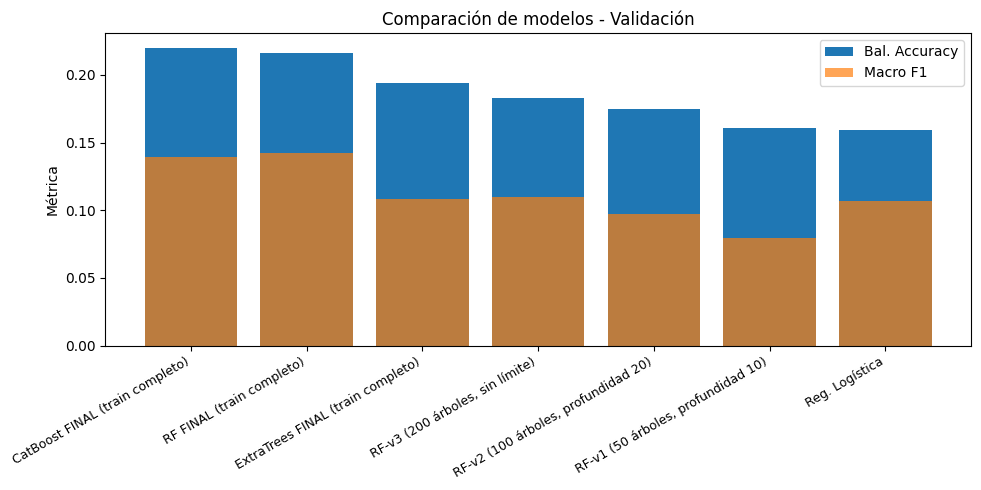

In [18]:
from sklearn.metrics import f1_score

# ── Tabla comparativa sobre validación ────────────────────────────────────
rows = []

# Regresión Logística
rows.append({
    'Modelo'       : 'Reg. Logística',
    'Accuracy'     : round(accuracy_score(y_valid, y_pred_lr_valid), 4),
    'Bal. Accuracy': round(balanced_accuracy_score(y_valid, y_pred_lr_valid), 4),
    'Macro F1'     : round(f1_score(y_valid, y_pred_lr_valid, average='macro', zero_division=0), 4),
})

# RF-v1, v2, v3 (resultados del barrido)
for r in rf_results:
    rows.append({
        'Modelo'       : r['Modelo'],
        'Accuracy'     : r['Valid Acc'],
        'Bal. Accuracy': r['Valid Bal.Acc'],
        'Macro F1'     : round(f1_score(y_valid, r['_y_pred_val'], average='macro', zero_division=0), 4),
    })

# RF final (entrenado en todo el train)
rows.append({
    'Modelo'       : 'RF FINAL (train completo)',
    'Accuracy'     : round(accuracy_score(y_valid, y_pred_rf_valid), 4),
    'Bal. Accuracy': round(balanced_accuracy_score(y_valid, y_pred_rf_valid), 4),
    'Macro F1'     : round(f1_score(y_valid, y_pred_rf_valid, average='macro', zero_division=0), 4),
})

# ExtraTrees final
rows.append({
    'Modelo'       : 'ExtraTrees FINAL (train completo)',
    'Accuracy'     : round(accuracy_score(y_valid, y_pred_et_valid_full), 4),
    'Bal. Accuracy': round(balanced_accuracy_score(y_valid, y_pred_et_valid_full), 4),
    'Macro F1'     : round(f1_score(y_valid, y_pred_et_valid_full, average='macro', zero_division=0), 4),
})

# CatBoost final
rows.append({
    'Modelo'       : 'CatBoost FINAL (train completo)',
    'Accuracy'     : round(accuracy_score(y_valid, y_pred_cb_valid_full), 4),
    'Bal. Accuracy': round(balanced_accuracy_score(y_valid, y_pred_cb_valid_full), 4),
    'Macro F1'     : round(f1_score(y_valid, y_pred_cb_valid_full, average='macro', zero_division=0), 4),
})

df_compare = pd.DataFrame(rows).sort_values('Bal. Accuracy', ascending=False).reset_index(drop=True)
print('Comparación de modelos (conjunto de VALIDACIÓN):')
display(df_compare)

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_compare))
ax.bar(x, df_compare['Bal. Accuracy'], label='Bal. Accuracy')
ax.bar(x, df_compare['Macro F1'],      label='Macro F1', alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels(df_compare['Modelo'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Métrica')
ax.set_title('Comparación de modelos - Validación')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# ── Evaluación final en TEST (se usa una sola vez) ────────────────────────
# Se selecciona el mejor modelo entre RF final y ExtraTrees final

best_valid_rf = balanced_accuracy_score(y_valid, y_pred_rf_valid)
best_valid_et = balanced_accuracy_score(y_valid, y_pred_et_valid_full)
best_valid_cb = balanced_accuracy_score(y_valid, y_pred_cb_valid_full)

# Seleccionar el mejor entre RF, ExtraTrees y CatBoost según Balanced Accuracy en validación
if best_valid_rf >= best_valid_et and best_valid_rf >= best_valid_cb:
    best_pipe   = best_rf_pipe
    best_nombre = f'RF FINAL ({best_rf_cfg["n_estimators"]} árboles, depth={best_rf_cfg["max_depth"]})'
elif best_valid_et >= best_valid_rf and best_valid_et >= best_valid_cb:
    best_pipe   = et_pipe
    best_nombre = 'ExtraTrees FINAL (150 árboles, depth=25)'
else:
    best_pipe   = cb_pipe
    best_nombre = 'CatBoost FINAL (train completo)'

print(f'Modelo seleccionado para evaluación en TEST: {best_nombre}')

y_pred_test = best_pipe.predict(X_test)

test_acc  = accuracy_score(y_test, y_pred_test)
test_bacc = balanced_accuracy_score(y_test, y_pred_test)
test_f1   = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

print(f'\nMétricas en TEST:')
print(f'  Accuracy          : {test_acc:.4f}')
print(f'  Balanced Accuracy : {test_bacc:.4f}')
print(f'  Macro F1          : {test_f1:.4f}')

print('\nReporte por clase:')
print(classification_report(y_test, y_pred_test, zero_division=0))

Modelo seleccionado para evaluación en TEST: CatBoost FINAL (train completo)

Métricas en TEST:
  Accuracy          : 0.1877
  Balanced Accuracy : 0.2192
  Macro F1          : 0.1394

Reporte por clase:
                               precision    recall  f1-score   support

  Accidentes_no_intencionales       0.36      0.05      0.08      9045
          Accidentes_transito       0.15      0.27      0.20      2216
                  Apendicitis       0.01      0.15      0.02       124
       Causa_mal_definida_R99       0.24      0.23      0.24      4089
              Cerebrovascular       0.13      0.06      0.08      5135
           Codigos_especiales       0.25      0.75      0.37      3687
                   Congenitas       0.17      0.43      0.25      1976
               Cronica_higado       0.14      0.16      0.15      5136
                         EPOC       0.04      0.20      0.07      1703
Efectos_adversos_medicamentos       0.00      0.00      0.00        14
     Embarazo_p

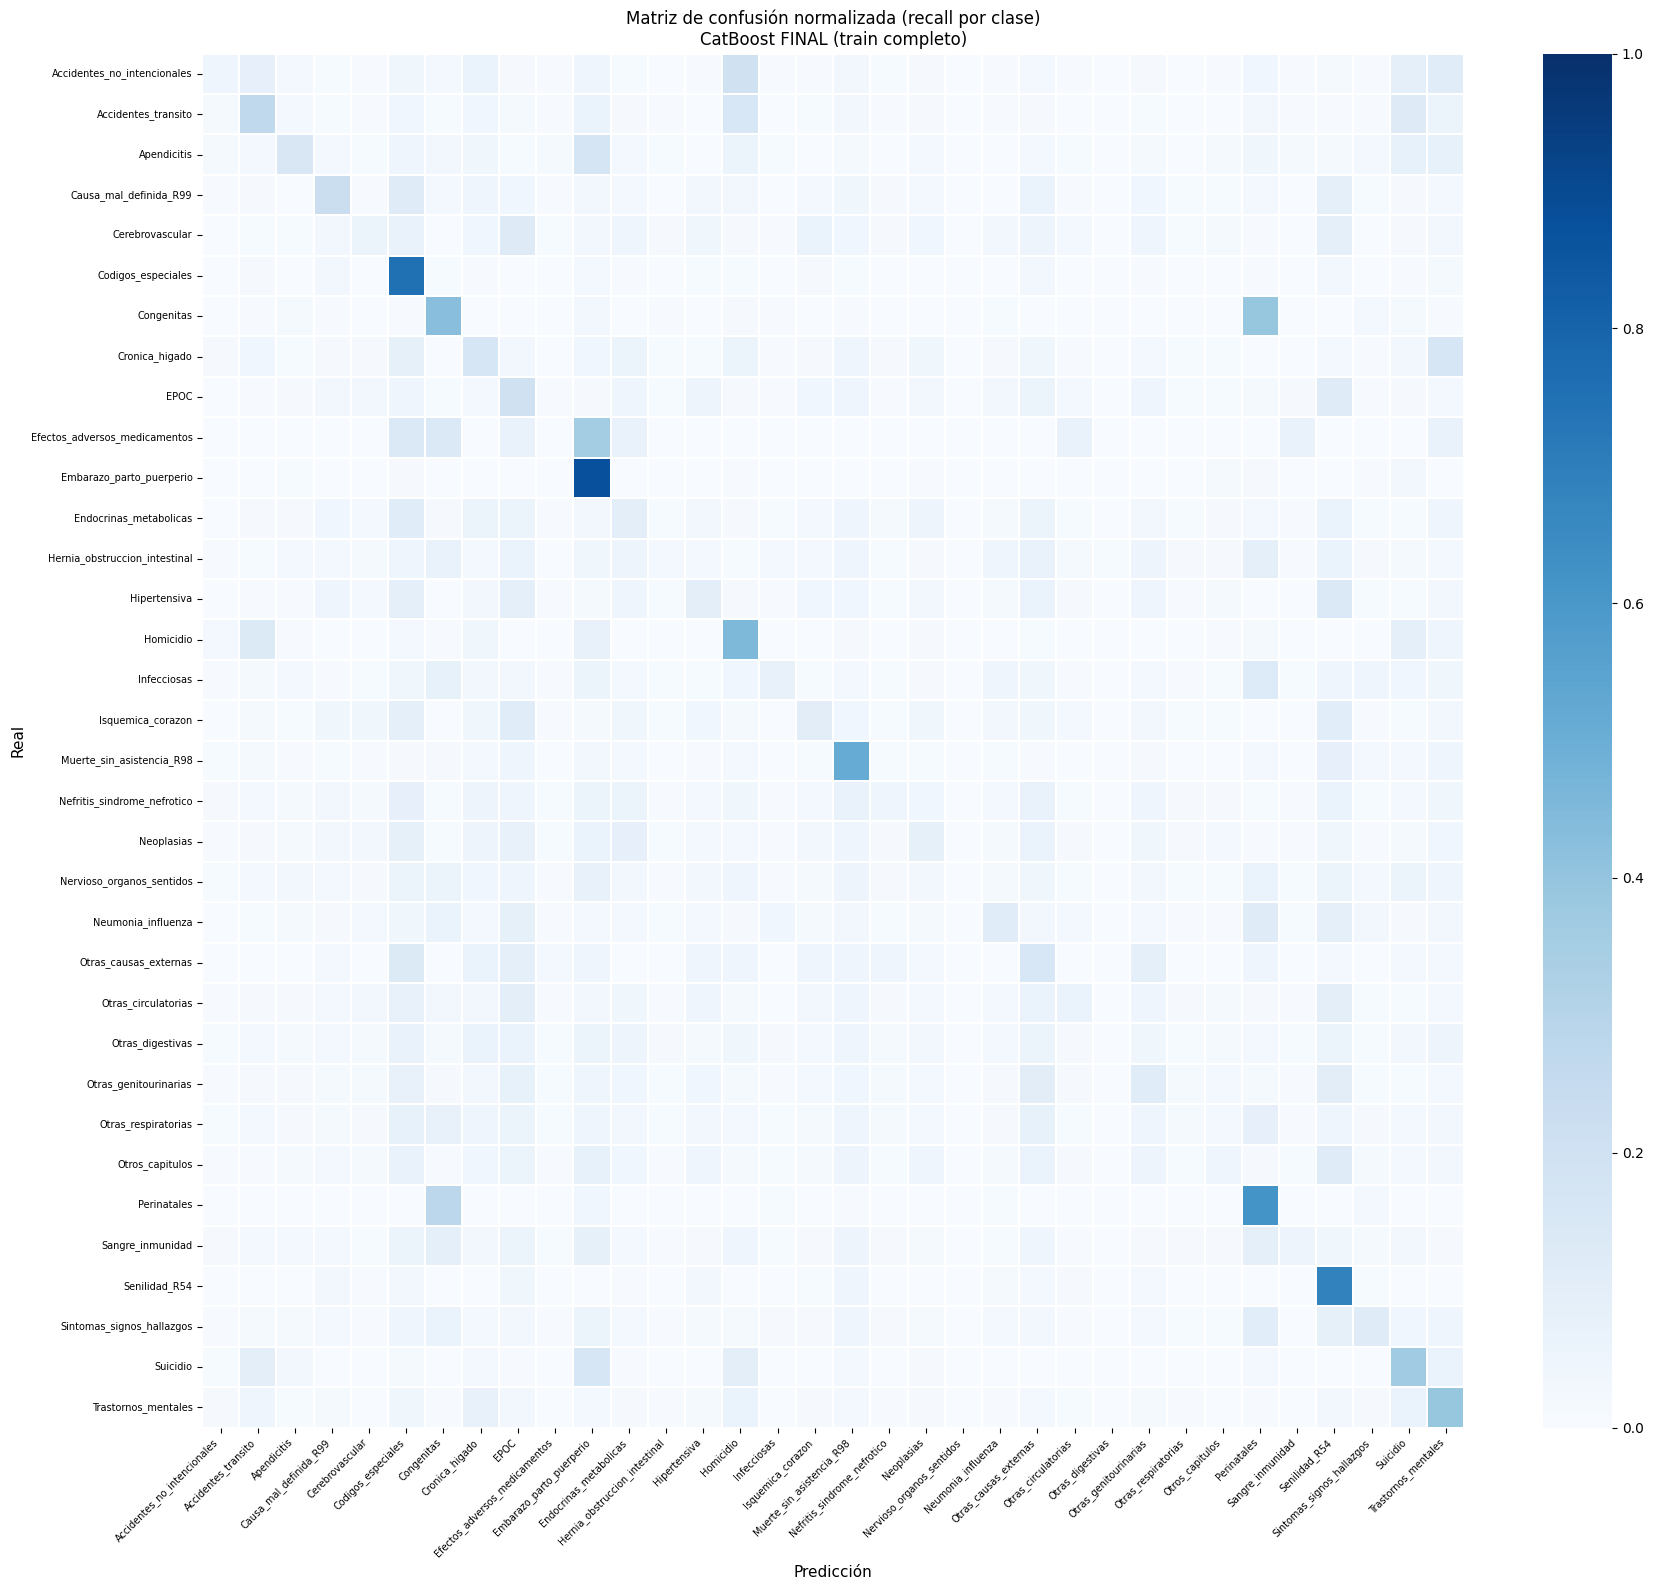

In [20]:
# ── Matriz de confusión normalizada por fila (recall por clase) ───────────
classes = best_pipe.classes_
cm = confusion_matrix(y_test, y_pred_test, labels=classes, normalize='true')

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm,
    xticklabels=classes,
    yticklabels=classes,
    cmap='Blues',
    vmin=0, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax,
)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title(f'Matriz de confusión normalizada (recall por clase)\n{best_nombre}', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

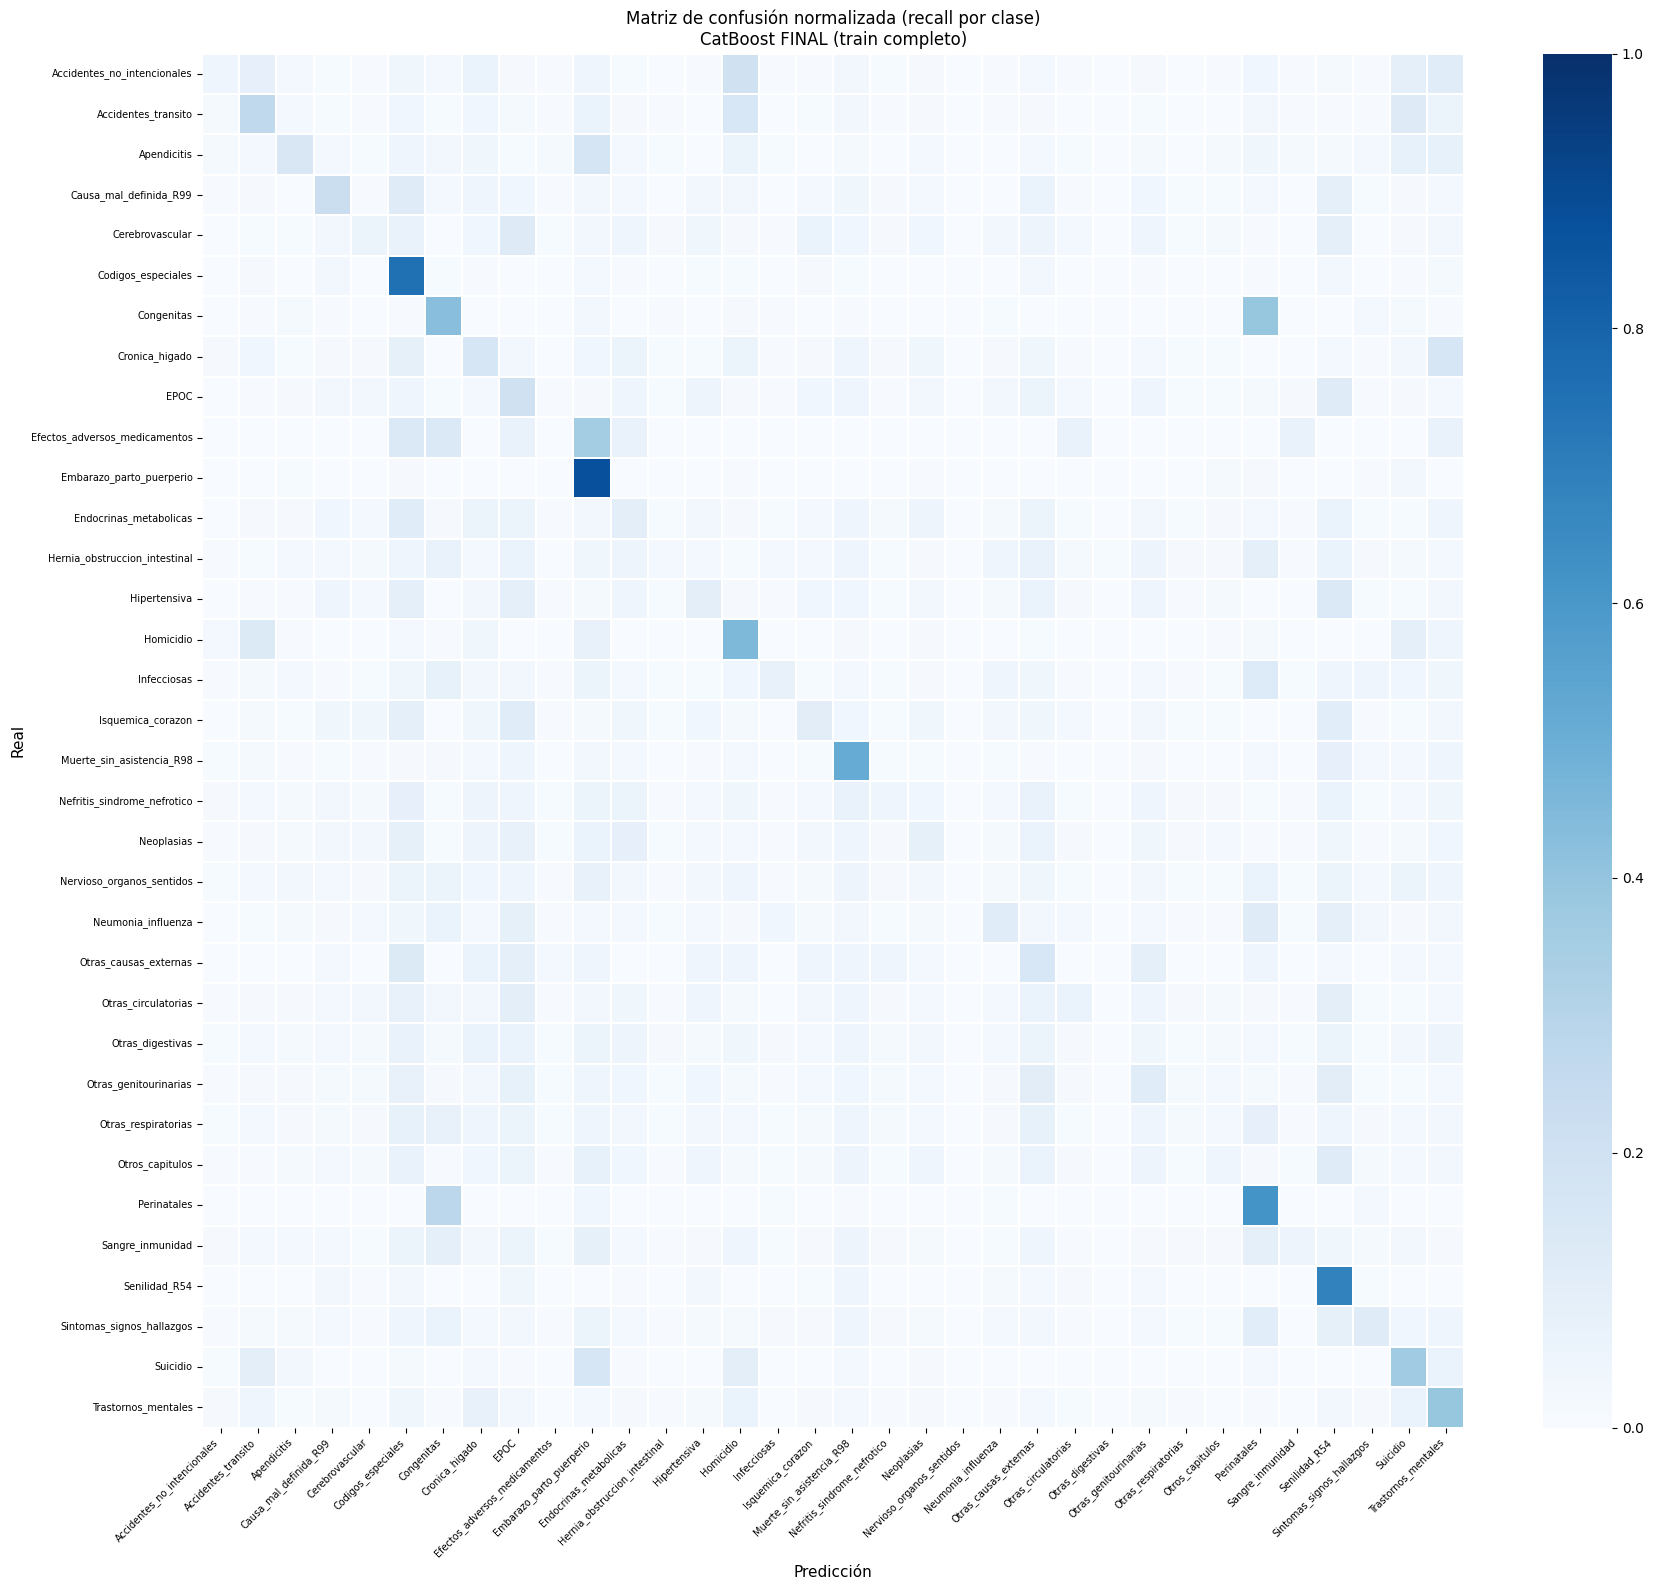

In [21]:
# ── Mostrar matriz de confusión (34 clases) en pantalla  ─────
classes = best_pipe.classes_
cm = confusion_matrix(y_test, y_pred_test, labels=classes, normalize='true')

fig_cm34, ax_cm34 = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm,
    xticklabels=classes,
    yticklabels=classes,
    cmap='Blues',
    vmin=0, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax_cm34,
)
ax_cm34.set_xlabel('Predicción', fontsize=11)
ax_cm34.set_ylabel('Real', fontsize=11)
ax_cm34.set_title(f'Matriz de confusión normalizada (recall por clase)\n{best_nombre}', fontsize=12)
ax_cm34.set_xticklabels(ax_cm34.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax_cm34.set_yticklabels(ax_cm34.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

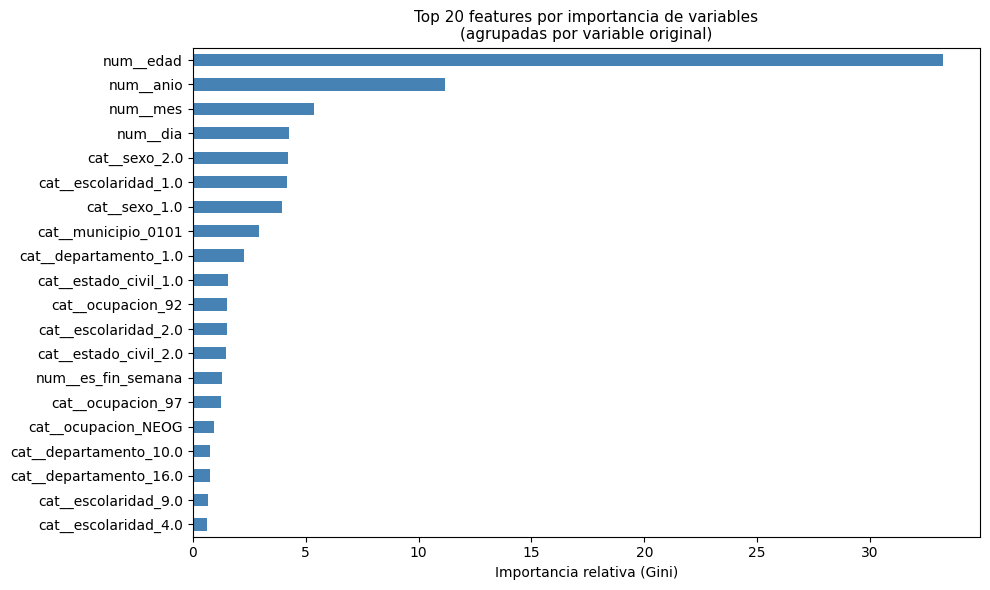

In [22]:
# ── Importancia de variables (RF / ExtraTrees) ───────────────────────────
clf_fitted = best_pipe.named_steps['clf']
prep_fitted = best_pipe.named_steps['prep']

ohe = prep_fitted.named_transformers_['cat'].named_steps['ohe']
cat_names = list(ohe.get_feature_names_out(cat_features))
feature_names = num_features + ['es_fin_semana'] + cat_names if 'es_fin_semana' not in num_features else num_features + cat_names

importances = clf_fitted.feature_importances_
ohe_feature_names = prep_fitted.get_feature_names_out()

imp_series = pd.Series(importances, index=ohe_feature_names)

def group_prefix(name: str) -> str:
    parts = name.split('__')
    if len(parts) >= 3:
        return parts[1] + '__' + parts[2].split('_')[0]
    return name

imp_grouped = imp_series.groupby(imp_series.index.map(group_prefix)).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
imp_grouped.head(20).plot.barh(ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Importancia relativa (Gini)', fontsize=10)
ax.set_title('Top 20 features por importancia de variables\n(agrupadas por variable original)', fontsize=11)
plt.tight_layout()
plt.show()

## Discusión de resultados

### Observaciones esperadas en el barrido de RF

| Versión | Comportamiento esperado |
|---------|------------------------|
| RF-v1 (depth=10) | Bal. Accuracy más baja. Los árboles superficiales no capturan la interacción edad × ocupación × departamento necesaria para distinguir, por ejemplo, `Perinatales` de `Congenitas`. → **Underfitting**. |
| RF-v2 (depth=20) | Mejora significativa sobre v1. El modelo captura más interacciones sin memorizar el ruido de registro. → **Punto óptimo**. |
| RF-v3 (depth=None) | Train Bal.Acc muy alta pero Valid Bal.Acc similar o ligeramente inferior a v2. Gap > 0 pero dentro de lo esperable. Si el gap es grande (>0.05), confirma **overfitting** sobre la muestra de 60 000. |

### Interpretación epidemiológica esperada de la matriz de confusión

- **Diagonal alta**: clases con patrones demográficos muy distintos (`Perinatales` edad≈0, `Homicidio` hombre joven, `Senilidad_R54` edad alta) se predicen bien.
- **Confusiones frecuentes esperadas**: dentro del capítulo circulatorio (`Hipertensiva` ↔ `Otras_circulatorias`), entre `Infecciosas` y `Neumonia_influenza`, y entre los códigos R (`R98`, `R99`, `R54`).
- **Clases difíciles**: `Efectos_adversos_medicamentos` (98 registros totales) y `Otras_causas_externas` (297) tienen muy pocas muestras; incluso con `class_weight='balanced'` el modelo puede fallar en estas clases.

### Variables más importantes (esperado)
- `edad` domina: la distribución etaria es el predictor más potente de causa de muerte (Perinatales, Senilidad, Isquémica, Accidentes de tránsito).
- `sexo`: Homicidio y accidentes de tránsito se concentran en hombres; Embarazo_parto solo en mujeres.
- `ocupacion` y `escolaridad`: correlacionan con el nivel socioeconómico y el acceso a diagnóstico, influyendo en las causas registradas.
- `departamento`: heterogeneidad geográfica en causas externas (Este del país) vs. causas infecciosas (Altiplano occidental).

### Limitaciones del modelo
1. **Variables ausentes**: el nivel de asistencia médica (`Asist`), el área geográfica (`Areag`) y el año de ocurrencia (`Añoocu`) con registros pre-2015 incompletos afectan la señal.
2. **Calidad del dato**: los códigos R representan ~12 % de los registros. Un certificante que usa R99 en lugar de un código específico introduce ruido estructural no recuperable por el modelo.
3. **No causalidad**: el modelo predice la causa registrada (etiqueta), no la causa real de muerte. Un recall bajo en clases como `Apendicitis` puede reflejar escasez de datos, no falla del algoritmo.

---

## Mejora del modelo: consolidación de clases + nuevas features

### Diagnóstico de los resultados anteriores

El RF con 34 clases alcanzó una **Balanced Accuracy de 0.216** (~6× mejor que el azar). El problema no es el algoritmo sino la granularidad: distinguir `Hipertensiva` de `Cerebrovascular` de `Isquemica_corazon` a partir de variables demográficas es casi imposible porque comparten el mismo perfil (adultos mayores, ambos sexos, todos los departamentos).

### Dos mejoras aplicadas

**1. Consolidar 34 → 9 macro-grupos**  
Se agrupan las clases CIE-10 en categorías epidemiológicamente coherentes. Esto reduce la dificultad del problema sin perder valor analítico.

| Macro-grupo | Clases incluidas |
|------------|-----------------|
| `Cardiovasculares` | Hipertensiva, Isquemica_corazon, Cerebrovascular, Otras_circulatorias |
| `Neoplasias` | Neoplasias, Sangre_inmunidad |
| `Causas_externas` | Homicidio, Accidentes_transito, Accidentes_no_intencionales, Suicidio, Otras_causas_externas, Efectos_adversos_medicamentos |
| `Infecciosas_respiratorias` | Infecciosas, Neumonia_influenza, EPOC, Otras_respiratorias |
| `Endocrinas_metabolicas` | Endocrinas_metabolicas |
| `Digestivas_genitourinarias` | Cronica_higado, Otras_digestivas, Apendicitis, Hernia_obstruccion_intestinal, Nefritis_sindrome_nefrotico, Otras_genitourinarias |
| `Materno_perinatal` | Perinatales, Congenitas, Embarazo_parto_puerperio |
| `Mal_definidas` | Muerte_sin_asistencia_R98, Causa_mal_definida_R99, Senilidad_R54, Sintomas_signos_hallazgos, Codigos_especiales |
| `Otras` | Nervioso_organos_sentidos, Trastornos_mentales, Otros_capitulos |

**2. Agregar `Areag` (urbano/rural) y `Ocur` (lugar de muerte)**  
`Ocur` es especialmente discriminativo: homicidios ocurren en vía pública, partos en hospitales, senilidad en domicilio. Estas variables estaban disponibles en el dataset pero no se habían incluido.

In [23]:
# ── 1. Mapa de consolidación 34 → 9 macro-grupos ─────────────────────────
MACRO_MAP = {
    # Cardiovasculares
    'Hipertensiva'              : 'Cardiovasculares',
    'Isquemica_corazon'         : 'Cardiovasculares',
    'Cerebrovascular'           : 'Cardiovasculares',
    'Otras_circulatorias'       : 'Cardiovasculares',
    # Neoplasias
    'Neoplasias'                : 'Neoplasias',
    'Sangre_inmunidad'          : 'Neoplasias',
    # Causas externas
    'Homicidio'                 : 'Causas_externas',
    'Accidentes_transito'       : 'Causas_externas',
    'Accidentes_no_intencionales': 'Causas_externas',
    'Suicidio'                  : 'Causas_externas',
    'Otras_causas_externas'     : 'Causas_externas',
    'Efectos_adversos_medicamentos': 'Causas_externas',
    # Infecciosas / respiratorias
    'Infecciosas'               : 'Infecciosas_respiratorias',
    'Neumonia_influenza'        : 'Infecciosas_respiratorias',
    'EPOC'                      : 'Infecciosas_respiratorias',
    'Otras_respiratorias'       : 'Infecciosas_respiratorias',
    # Endocrinas / metabólicas
    'Endocrinas_metabolicas'    : 'Endocrinas_metabolicas',
    # Digestivas / genitourinarias
    'Cronica_higado'            : 'Digestivas_genitourinarias',
    'Otras_digestivas'          : 'Digestivas_genitourinarias',
    'Apendicitis'               : 'Digestivas_genitourinarias',
    'Hernia_obstruccion_intestinal': 'Digestivas_genitourinarias',
    'Nefritis_sindrome_nefrotico': 'Digestivas_genitourinarias',
    'Otras_genitourinarias'     : 'Digestivas_genitourinarias',
    # Materno-perinatal
    'Perinatales'               : 'Materno_perinatal',
    'Congenitas'                : 'Materno_perinatal',
    'Embarazo_parto_puerperio'  : 'Materno_perinatal',
    # Mal definidas / calidad del dato
    'Muerte_sin_asistencia_R98' : 'Mal_definidas',
    'Causa_mal_definida_R99'    : 'Mal_definidas',
    'Senilidad_R54'             : 'Mal_definidas',
    'Sintomas_signos_hallazgos' : 'Mal_definidas',
    'Codigos_especiales'        : 'Mal_definidas',
    # Otras
    'Nervioso_organos_sentidos' : 'Otras',
    'Trastornos_mentales'       : 'Otras',
    'Otros_capitulos'           : 'Otras',
}

y_macro = df['grupo_causa_cie10'].map(MACRO_MAP)
print('Distribución de macro-grupos:')
display(
    y_macro.value_counts()
    .to_frame('conteo')
    .assign(pct=lambda d: (d['conteo'] / d['conteo'].sum() * 100).round(2))
)
print(f'\nClases sin mapeo: {y_macro.isna().sum()}')

Distribución de macro-grupos:


,conteo,pct
grupo_causa_cie10,,
Cardiovasculares,145330,16.55
Infecciosas_respiratorias,128861,14.67
Mal_definidas,127725,14.55
Causas_externas,115560,13.16
Digestivas_genitourinarias,104241,11.87
Endocrinas_metabolicas,91789,10.45
Neoplasias,91775,10.45
Materno_perinatal,44778,5.10
Otras,28077,3.20



Clases sin mapeo: 0


In [24]:
# ── 2. Agregar Areag y Ocur al dataset de modelado ────────────────────────
areag_col = resolve_column(df, ['Areag'])
ocur_col  = resolve_column(df, ['Ocur'])

print(f'Areag detectado: {areag_col}')
print(f'Ocur  detectado: {ocur_col}')

df_model2 = df_model.copy()

if areag_col:
    df_model2['area_geografica'] = df[areag_col].values
    print(f'\nValores únicos Areag: {df[areag_col].value_counts().to_dict()}')

if ocur_col:
    df_model2['lugar_ocurrencia'] = df[ocur_col].values
    print(f'\nValores únicos Ocur:\n{df[ocur_col].value_counts().head(10)}')

y_macro2 = y_macro.copy()

print(f'\nShape X mejorado: {df_model2.shape}')
print(f'Shape y macro:    {y_macro2.shape}')

Areag detectado: Areag
Ocur  detectado: Ocur

Valores únicos Areag: {1.0: 220220, 2.0: 172113, 9.0: 7280}

Valores únicos Ocur:
Ocur
6.0    544899
1.0    180961
9.0     48948
4.0     46517
2.0     24462
5.0     21365
8.0      8499
3.0      2452
7.0        33
Name: count, dtype: int64

Shape X mejorado: (878136, 13)
Shape y macro:    (878136,)


In [25]:
# ── 3. Nuevo split estratificado con macro-grupos ─────────────────────────
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    df_model2, y_macro2,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_macro2,
)
X2_valid, X2_test, y2_valid, y2_test = train_test_split(
    X2_temp, y2_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y2_temp,
)

print(f'Train: {X2_train.shape}  Valid: {X2_valid.shape}  Test: {X2_test.shape}')

# Balance del nuevo y
print('\nDistribución en train (macro-grupos):')
display(y2_train.value_counts(normalize=True).mul(100).round(2).to_frame('%'))

# ── 4. Nuevo preprocesador con las features adicionales ───────────────────
extra_cat = [c for c in ['area_geografica', 'lugar_ocurrencia'] if c in df_model2.columns]
cat_features2 = cat_features + extra_cat

preprocessor2 = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ]), cat_features2),
], remainder='drop')

print(f'\nFeatures categóricas ahora: {cat_features2}')

# Muestra estratificada para barrido
idx2, _ = train_test_split(
    range(len(X2_train)),
    train_size=SWEEP_SIZE,
    random_state=RANDOM_STATE,
    stratify=y2_train,
)
X2_sw = X2_train.iloc[idx2].reset_index(drop=True)
y2_sw = y2_train.iloc[idx2].reset_index(drop=True)

Train: (614695, 13)  Valid: (131720, 13)  Test: (131721, 13)

Distribución en train (macro-grupos):


,%
grupo_causa_cie10,
Cardiovasculares,16.55
Infecciosas_respiratorias,14.67
Mal_definidas,14.54
Causas_externas,13.16
Digestivas_genitourinarias,11.87
Endocrinas_metabolicas,10.45
Neoplasias,10.45
Materno_perinatal,5.10
Otras,3.20



Features categóricas ahora: ['sexo', 'departamento', 'municipio', 'estado_civil', 'escolaridad', 'ocupacion', 'area_geografica', 'lugar_ocurrencia']


In [26]:
# ── 5. Barrido RF con macro-grupos (3 versiones) ──────────────────────────
rf_configs2 = [
    {'nombre': 'RF-v1 macro (50, depth 10)',   'n_estimators': 50,  'max_depth': 10},
    {'nombre': 'RF-v2 macro (100, depth 20)',  'n_estimators': 100, 'max_depth': 20},
    {'nombre': 'RF-v3 macro (200, sin límite)','n_estimators': 200, 'max_depth': None},
]

rf2_results = []

for cfg in rf_configs2:
    pipe2 = Pipeline([
        ('prep', preprocessor2),
        ('clf',  RandomForestClassifier(
            n_estimators=cfg['n_estimators'],
            max_depth=cfg['max_depth'],
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    t0 = time.time()
    pipe2.fit(X2_sw, y2_sw)
    t_train = time.time() - t0

    y_pred_sw2  = pipe2.predict(X2_sw)
    train_bacc2 = balanced_accuracy_score(y2_sw, y_pred_sw2)

    y_pred_val2  = pipe2.predict(X2_valid)
    valid_acc2   = accuracy_score(y2_valid, y_pred_val2)
    valid_bacc2  = balanced_accuracy_score(y2_valid, y_pred_val2)
    gap2         = train_bacc2 - valid_bacc2

    rf2_results.append({
        'Modelo'            : cfg['nombre'],
        'Train Bal.Acc'     : round(train_bacc2, 4),
        'Valid Acc'         : round(valid_acc2, 4),
        'Valid Bal.Acc'     : round(valid_bacc2, 4),
        'Gap'               : round(gap2, 4),
        'Tiempo (s)'        : round(t_train, 1),
        '_pipe'             : pipe2,
        '_y_pred_val'       : y_pred_val2,
        '_cfg'              : cfg,
    })

    estado = '⚠ OVERFIT' if gap2 > 0.05 else ('⚠ UNDERFIT' if valid_bacc2 < 0.30 else '✓ OK')
    print(f'{cfg["nombre"]}')
    print(f'  Train={train_bacc2:.4f}  Valid Bal.Acc={valid_bacc2:.4f}  Gap={gap2:.4f}  {estado}  [{t_train:.1f}s]\n')

df_rf2 = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in rf2_results])
print('Resumen barrido (macro-grupos):')
display(df_rf2)

RF-v1 macro (50, depth 10)
  Train=0.3741  Valid Bal.Acc=0.3532  Gap=0.0209  ✓ OK  [0.6s]

RF-v2 macro (100, depth 20)
  Train=0.4428  Valid Bal.Acc=0.3795  Gap=0.0633  ⚠ OVERFIT  [1.3s]

RF-v3 macro (200, sin límite)
  Train=0.4956  Valid Bal.Acc=0.3880  Gap=0.1076  ⚠ OVERFIT  [3.4s]

Resumen barrido (macro-grupos):


,Modelo,Train Bal.Acc,Valid Acc,Valid Bal.Acc,Gap,Tiempo (s)
0,"RF-v1 macro (50, depth 10)",0.3741,0.3476,0.3532,0.0209,0.6
1,"RF-v2 macro (100, depth 20)",0.4428,0.3788,0.3795,0.0633,1.3
2,"RF-v3 macro (200, sin límite)",0.4956,0.3882,0.3880,0.1076,3.4


In [27]:
# ── 6. Modelo final mejorado: reentrenar sobre todo el train ──────────────
best2_idx = max(range(len(rf2_results)), key=lambda i: rf2_results[i]['Valid Bal.Acc'])
best2_cfg = rf2_results[best2_idx]['_cfg']

print(f'Mejor configuración macro: {best2_cfg["nombre"]}')

best_pipe2 = Pipeline([
    ('prep', preprocessor2),
    ('clf',  RandomForestClassifier(
        n_estimators=best2_cfg['n_estimators'],
        max_depth=best2_cfg['max_depth'],
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

t0 = time.time()
best_pipe2.fit(X2_train, y2_train)
print(f'Entrenamiento final: {time.time() - t0:.1f} s')

y2_pred_valid = best_pipe2.predict(X2_valid)
y2_pred_test  = best_pipe2.predict(X2_test)

print('\n── Validación ──')
print(f'  Accuracy          : {accuracy_score(y2_valid, y2_pred_valid):.4f}')
print(f'  Balanced Accuracy : {balanced_accuracy_score(y2_valid, y2_pred_valid):.4f}')
print(f'  Macro F1          : {f1_score(y2_valid, y2_pred_valid, average="macro", zero_division=0):.4f}')

print('\n── TEST (evaluación final) ──')
test2_acc  = accuracy_score(y2_test, y2_pred_test)
test2_bacc = balanced_accuracy_score(y2_test, y2_pred_test)
test2_f1   = f1_score(y2_test, y2_pred_test, average='macro', zero_division=0)
print(f'  Accuracy          : {test2_acc:.4f}')
print(f'  Balanced Accuracy : {test2_bacc:.4f}')
print(f'  Macro F1          : {test2_f1:.4f}')

print('\nReporte por clase (TEST):')
print(classification_report(y2_test, y2_pred_test, zero_division=0))

Mejor configuración macro: RF-v3 macro (200, sin límite)
Entrenamiento final: 261.9 s

── Validación ──
  Accuracy          : 0.4123
  Balanced Accuracy : 0.4133
  Macro F1          : 0.3819

── TEST (evaluación final) ──
  Accuracy          : 0.4111
  Balanced Accuracy : 0.4121
  Macro F1          : 0.3807

Reporte por clase (TEST):
                            precision    recall  f1-score   support

          Cardiovasculares       0.40      0.35      0.37     21800
           Causas_externas       0.66      0.83      0.73     17334
Digestivas_genitourinarias       0.27      0.20      0.23     15636
    Endocrinas_metabolicas       0.25      0.24      0.24     13769
 Infecciosas_respiratorias       0.46      0.29      0.36     19329
             Mal_definidas       0.50      0.51      0.50     19159
         Materno_perinatal       0.44      0.85      0.58      6716
                Neoplasias       0.27      0.29      0.28     13767
                     Otras       0.11      0.15    

In [28]:
# ── Modelo 2 mejorado: Logistic Regression con macro-grupos ───────────────
lr_pipe2 = Pipeline([
    ('prep', preprocessor2),
    ('clf',  LogisticRegression(
        solver='saga',
        max_iter=500,
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

t0 = time.time()
lr_pipe2.fit(X2_sw, y2_sw)
t_lr2_sw = time.time() - t0

y_pred_lr2_sw = lr_pipe2.predict(X2_sw)
lr2_train_bacc = balanced_accuracy_score(y2_sw, y_pred_lr2_sw)

y_pred_lr2_valid = lr_pipe2.predict(X2_valid)
lr2_valid_acc = accuracy_score(y2_valid, y_pred_lr2_valid)
lr2_valid_bacc = balanced_accuracy_score(y2_valid, y_pred_lr2_valid)
lr2_gap = lr2_train_bacc - lr2_valid_bacc

print('Logistic Regression - macro-grupos (muestra 60 000)')
print(f'  Train Bal.Acc = {lr2_train_bacc:.4f}')
print(f'  Valid Acc     = {lr2_valid_acc:.4f}')
print(f'  Valid Bal.Acc = {lr2_valid_bacc:.4f}')
print(f'  Gap           = {lr2_gap:.4f}')
print(f'  Tiempo (s)    = {t_lr2_sw:.1f}')

# Reentrenar sobre conjunto completo
t0 = time.time()
lr_pipe2.fit(X2_train, y2_train)
t_lr2_full = time.time() - t0
print(f'\nEntrenamiento final LR: {t_lr2_full:.1f} s  (train completo {len(X2_train):,})')

y_pred_lr2_valid_full = lr_pipe2.predict(X2_valid)
print(f'Valid Accuracy         : {accuracy_score(y2_valid, y_pred_lr2_valid_full):.4f}')
print(f'Valid Balanced Accuracy: {balanced_accuracy_score(y2_valid, y_pred_lr2_valid_full):.4f}')

Logistic Regression - macro-grupos (muestra 60 000)
  Train Bal.Acc = 0.4011
  Valid Acc     = 0.3699
  Valid Bal.Acc = 0.3770
  Gap           = 0.0242
  Tiempo (s)    = 24.4

Entrenamiento final LR: 331.7 s  (train completo 614,695)
Valid Accuracy         : 0.3788
Valid Balanced Accuracy: 0.3852


In [29]:
# ── Modelo 3 mejorado: ExtraTrees con macro-grupos ────────────────────────
et_pipe2 = Pipeline([
    ('prep', preprocessor2),
    ('clf',  ExtraTreesClassifier(
        n_estimators=150,
        max_depth=25,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

t0 = time.time()
et_pipe2.fit(X2_sw, y2_sw)
t_et2_sw = time.time() - t0

y_pred_et2_sw = et_pipe2.predict(X2_sw)
et2_train_bacc = balanced_accuracy_score(y2_sw, y_pred_et2_sw)

y_pred_et2_valid = et_pipe2.predict(X2_valid)
et2_valid_acc = accuracy_score(y2_valid, y_pred_et2_valid)
et2_valid_bacc = balanced_accuracy_score(y2_valid, y_pred_et2_valid)
et2_gap = et2_train_bacc - et2_valid_bacc

print('ExtraTrees - macro-grupos (muestra 60 000)')
print(f'  Train Bal.Acc = {et2_train_bacc:.4f}')
print(f'  Valid Acc     = {et2_valid_acc:.4f}')
print(f'  Valid Bal.Acc = {et2_valid_bacc:.4f}')
print(f'  Gap           = {et2_gap:.4f}')
print(f'  Tiempo (s)    = {t_et2_sw:.1f}')

# Reentrenar sobre conjunto completo
t0 = time.time()
et_pipe2.fit(X2_train, y2_train)
t_et2_full = time.time() - t0
print(f'\nEntrenamiento final ExtraTrees: {t_et2_full:.1f} s  (train completo {len(X2_train):,})')

y_pred_et2_valid_full = et_pipe2.predict(X2_valid)
print(f'Valid Accuracy         : {accuracy_score(y2_valid, y_pred_et2_valid_full):.4f}')
print(f'Valid Balanced Accuracy: {balanced_accuracy_score(y2_valid, y_pred_et2_valid_full):.4f}')

ExtraTrees - macro-grupos (muestra 60 000)
  Train Bal.Acc = 0.4632
  Valid Acc     = 0.3712
  Valid Bal.Acc = 0.3750
  Gap           = 0.0882
  Tiempo (s)    = 2.2

Entrenamiento final ExtraTrees: 116.6 s  (train completo 614,695)
Valid Accuracy         : 0.3851
Valid Balanced Accuracy: 0.3896


In [30]:
# ── Modelo 4 mejorado: CatBoost con macro-grupos ───────────────────────────
cb_pipe2 = Pipeline([
    ('prep', preprocessor2),
    ('clf', CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        verbose=0,
    )),
])

t0 = time.time()
cb_pipe2.fit(X2_sw, y2_sw)
t_cb2_sw = time.time() - t0

y_pred_cb2_sw = cb_pipe2.predict(X2_sw)
cb2_train_bacc = balanced_accuracy_score(y2_sw, y_pred_cb2_sw)

y_pred_cb2_valid = cb_pipe2.predict(X2_valid)
cb2_valid_acc = accuracy_score(y2_valid, y_pred_cb2_valid)
cb2_valid_bacc = balanced_accuracy_score(y2_valid, y_pred_cb2_valid)
cb2_gap = cb2_train_bacc - cb2_valid_bacc

print('CatBoost - macro-grupos (muestra 60 000)')
print(f'  Train Bal.Acc = {cb2_train_bacc:.4f}')
print(f'  Valid Acc     = {cb2_valid_acc:.4f}')
print(f'  Valid Bal.Acc = {cb2_valid_bacc:.4f}')
print(f'  Gap           = {cb2_gap:.4f}')
print(f'  Tiempo (s)    = {t_cb2_sw:.1f}')

# Reentrenar sobre conjunto completo
t0 = time.time()
cb_pipe2.fit(X2_train, y2_train)
t_cb2_full = time.time() - t0
print(f'\nEntrenamiento final CatBoost: {t_cb2_full:.1f} s  (train completo {len(X2_train):,})')

y_pred_cb2_valid_full = cb_pipe2.predict(X2_valid)
print(f'Valid Accuracy         : {accuracy_score(y2_valid, y_pred_cb2_valid_full):.4f}')
print(f'Valid Balanced Accuracy: {balanced_accuracy_score(y2_valid, y_pred_cb2_valid_full):.4f}')

CatBoost - macro-grupos (muestra 60 000)
  Train Bal.Acc = 0.4653
  Valid Acc     = 0.4058
  Valid Bal.Acc = 0.4067
  Gap           = 0.0586
  Tiempo (s)    = 13.1

Entrenamiento final CatBoost: 61.5 s  (train completo 614,695)
Valid Accuracy         : 0.4208
Valid Balanced Accuracy: 0.4229


Comparación de modelos mejorados (9 macro-grupos, VALIDACIÓN):


,Modelo,Accuracy,Bal. Accuracy,Macro F1
0,CatBoost FINAL (macro),0.4208,0.4229,0.3980
1,RF FINAL (macro),0.4123,0.4133,0.3819
2,ExtraTrees FINAL (macro),0.3851,0.3896,0.3551
3,Reg. Logística (macro),0.3788,0.3852,0.3511


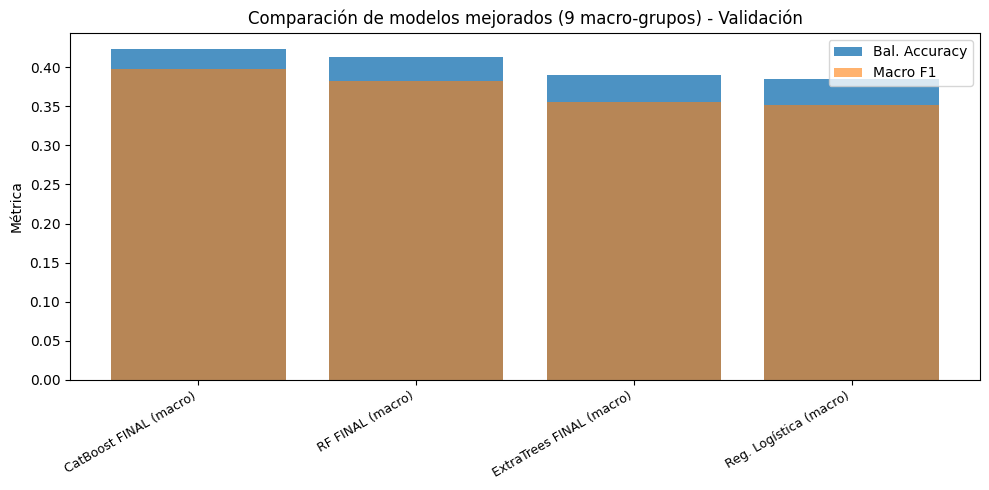

In [31]:
# ── Comparativa de todos los modelos mejorados (9 macro-grupos) ────────────
rows_macro = []

# Logistic Regression
rows_macro.append({
    'Modelo'       : 'Reg. Logística (macro)',
    'Accuracy'     : round(accuracy_score(y2_valid, y_pred_lr2_valid_full), 4),
    'Bal. Accuracy': round(balanced_accuracy_score(y2_valid, y_pred_lr2_valid_full), 4),
    'Macro F1'     : round(f1_score(y2_valid, y_pred_lr2_valid_full, average='macro', zero_division=0), 4),
})

# Random Forest
rows_macro.append({
    'Modelo'       : 'RF FINAL (macro)',
    'Accuracy'     : round(accuracy_score(y2_valid, y2_pred_valid), 4),
    'Bal. Accuracy': round(balanced_accuracy_score(y2_valid, y2_pred_valid), 4),
    'Macro F1'     : round(f1_score(y2_valid, y2_pred_valid, average='macro', zero_division=0), 4),
})

# ExtraTrees
rows_macro.append({
    'Modelo'       : 'ExtraTrees FINAL (macro)',
    'Accuracy'     : round(accuracy_score(y2_valid, y_pred_et2_valid_full), 4),
    'Bal. Accuracy': round(balanced_accuracy_score(y2_valid, y_pred_et2_valid_full), 4),
    'Macro F1'     : round(f1_score(y2_valid, y_pred_et2_valid_full, average='macro', zero_division=0), 4),
})

# CatBoost
rows_macro.append({
    'Modelo'       : 'CatBoost FINAL (macro)',
    'Accuracy'     : round(accuracy_score(y2_valid, y_pred_cb2_valid_full), 4),
    'Bal. Accuracy': round(balanced_accuracy_score(y2_valid, y_pred_cb2_valid_full), 4),
    'Macro F1'     : round(f1_score(y2_valid, y_pred_cb2_valid_full, average='macro', zero_division=0), 4),
})

df_compare_macro = pd.DataFrame(rows_macro).sort_values('Bal. Accuracy', ascending=False).reset_index(drop=True)
print('Comparación de modelos mejorados (9 macro-grupos, VALIDACIÓN):')
display(df_compare_macro)

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_compare_macro))
ax.bar(x, df_compare_macro['Bal. Accuracy'], label='Bal. Accuracy', alpha=0.8)
ax.bar(x, df_compare_macro['Macro F1'],      label='Macro F1', alpha=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(df_compare_macro['Modelo'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Métrica')
ax.set_title('Comparación de modelos mejorados (9 macro-grupos) - Validación')
ax.legend()
plt.tight_layout()
plt.show()

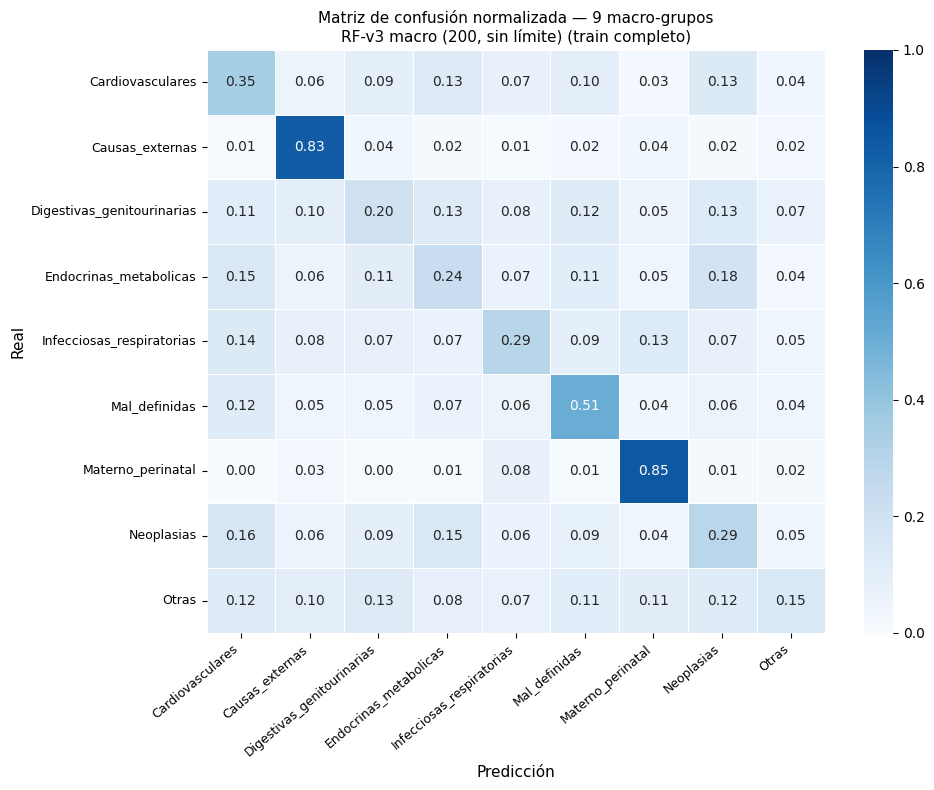

In [32]:
# ── 7. Matriz de confusión del modelo mejorado ────────────────────────────
classes2 = best_pipe2.classes_
cm2 = confusion_matrix(y2_test, y2_pred_test, labels=classes2, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm2,
    xticklabels=classes2,
    yticklabels=classes2,
    cmap='Blues',
    vmin=0, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title(f'Matriz de confusión normalizada — 9 macro-grupos\n{best2_cfg["nombre"]} (train completo)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

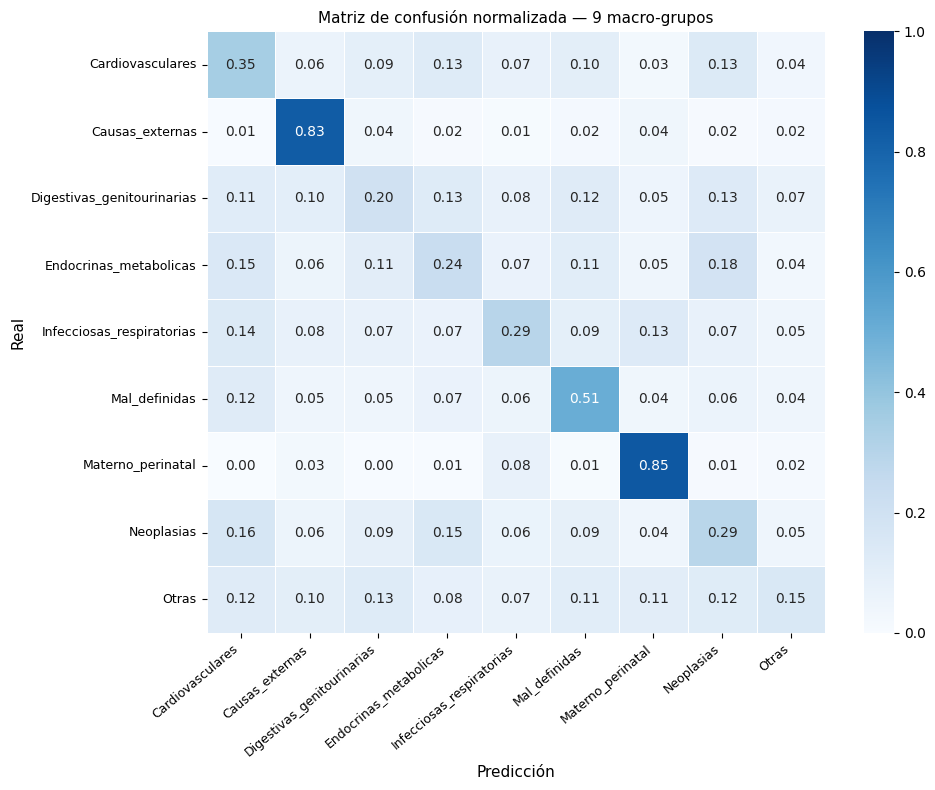

In [33]:
# ── Mostrar matriz de confusión (9 macro-grupos) en pantalla
cm2 = confusion_matrix(y2_test, y2_pred_test, labels=classes2, normalize='true')

fig_cm9, ax_cm9 = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm2,
    xticklabels=classes2,
    yticklabels=classes2,
    cmap='Blues',
    vmin=0, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax_cm9,
)
ax_cm9.set_xlabel('Predicción', fontsize=11)
ax_cm9.set_ylabel('Real', fontsize=11)
ax_cm9.set_title('Matriz de confusión normalizada — 9 macro-grupos', fontsize=11)
ax_cm9.set_xticklabels(ax_cm9.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax_cm9.set_yticklabels(ax_cm9.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Modelo seleccionado para TEST (9 macro-grupos): CatBoost
  Balanced Accuracy en validación: 0.4229

Métricas en TEST (9 macro-grupos):
  Accuracy          : 0.4203
  Balanced Accuracy : 0.4222
  Macro F1          : 0.3974

Reporte por clase (9 macro-grupos):
                            precision    recall  f1-score   support

          Cardiovasculares       0.39      0.39      0.39     21800
           Causas_externas       0.74      0.80      0.77     17334
Digestivas_genitourinarias       0.27      0.23      0.25     15636
    Endocrinas_metabolicas       0.25      0.26      0.25     13769
 Infecciosas_respiratorias       0.49      0.28      0.36     19329
             Mal_definidas       0.53      0.50      0.52     19159
         Materno_perinatal       0.48      0.85      0.62      6716
                Neoplasias       0.27      0.30      0.29     13767
                     Otras       0.11      0.18      0.14      4211

                  accuracy                           0.42  

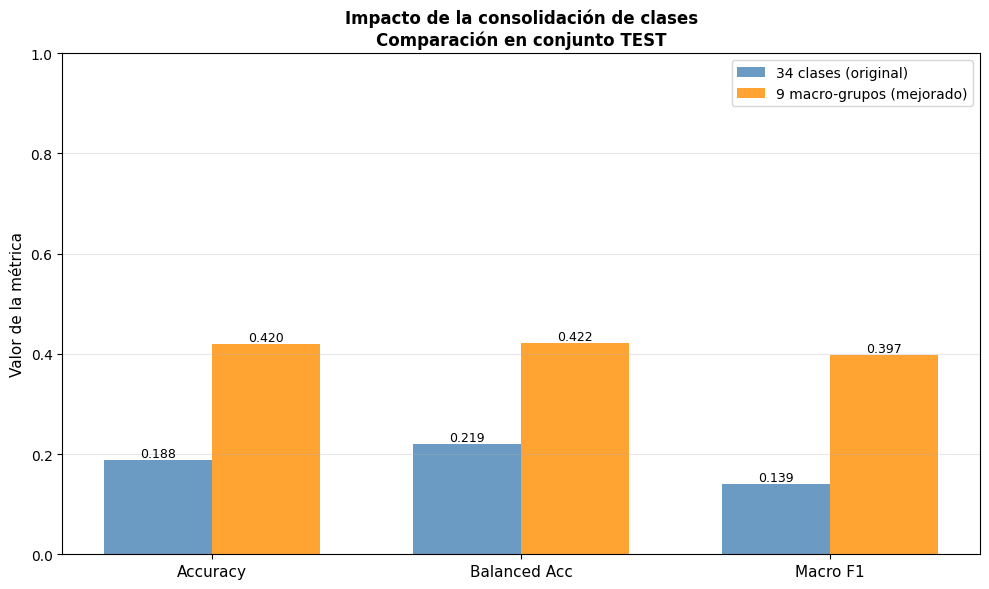

In [34]:
# ── Evaluación final en TEST con todos los modelos mejorados ───────────────
# Se selecciona el mejor modelo entre LR, RF, ExtraTrees y CatBoost

best_valid_lr2  = balanced_accuracy_score(y2_valid, y_pred_lr2_valid_full)
best_valid_rf2  = balanced_accuracy_score(y2_valid, y2_pred_valid)
best_valid_et2  = balanced_accuracy_score(y2_valid, y_pred_et2_valid_full)
best_valid_cb2  = balanced_accuracy_score(y2_valid, y_pred_cb2_valid_full)

# Determinar el mejor modelo
scores_macro = {
    'Reg. Logística': (best_valid_lr2, lr_pipe2),
    'Random Forest': (best_valid_rf2, best_pipe2),
    'ExtraTrees': (best_valid_et2, et_pipe2),
    'CatBoost': (best_valid_cb2, cb_pipe2),
}

best_name_macro, (best_score_macro, best_pipe_macro2) = max(scores_macro.items(), key=lambda x: x[1][0])

print(f'Modelo seleccionado para TEST (9 macro-grupos): {best_name_macro}')
print(f'  Balanced Accuracy en validación: {best_score_macro:.4f}')

y_pred_test2 = best_pipe_macro2.predict(X2_test)

test2_acc  = accuracy_score(y2_test, y_pred_test2)
test2_bacc = balanced_accuracy_score(y2_test, y_pred_test2)
test2_f1   = f1_score(y2_test, y_pred_test2, average='macro', zero_division=0)

print(f'\nMétricas en TEST (9 macro-grupos):')
print(f'  Accuracy          : {test2_acc:.4f}')
print(f'  Balanced Accuracy : {test2_bacc:.4f}')
print(f'  Macro F1          : {test2_f1:.4f}')

print('\nReporte por clase (9 macro-grupos):')
print(classification_report(y2_test, y_pred_test2, zero_division=0))

# ── Resumen comparativo final: 34 clases vs 9 macro-grupos ─────────────────
print('\n' + '=' * 70)
print('RESUMEN FINAL: IMPACTO DE CONSOLIDACIÓN (34 → 9 macro-grupos)')
print('=' * 70)

# Mejor modelo en 34 clases
print(f'\n📊 MODELO EN 34 CLASES (original):')
print(f'  Mejor modelo: {best_nombre}')
print(f'  Accuracy (test)         : {test_acc:.4f}')
print(f'  Balanced Accuracy (test): {test_bacc:.4f}')
print(f'  Macro F1 (test)         : {test_f1:.4f}')

# Mejor modelo en 9 macro-grupos
print(f'\n📊 MODELO EN 9 MACRO-GRUPOS (mejorado):')
print(f'  Mejor modelo: {best_name_macro}')
print(f'  Accuracy (test)         : {test2_acc:.4f}')
print(f'  Balanced Accuracy (test): {test2_bacc:.4f}')
print(f'  Macro F1 (test)         : {test2_f1:.4f}')

# Mejora calculada
mejora_acc  = ((test2_acc  - test_acc)  / test_acc)  * 100
mejora_bacc = ((test2_bacc - test_bacc) / test_bacc) * 100
mejora_f1   = ((test2_f1   - test_f1)   / test_f1)   * 100

print(f'\n📈 MEJORA con consolidación:')
print(f'  Accuracy      : {mejora_acc:+.1f}%')
print(f'  Balanced Acc  : {mejora_bacc:+.1f}%')
print(f'  Macro F1      : {mejora_f1:+.1f}%')
print('=' * 70)

# Gráfica de comparación lado a lado
labels  = ['Accuracy', 'Balanced Acc', 'Macro F1']
v34     = [test_acc,  test_bacc,  test_f1]
v9      = [test2_acc, test2_bacc, test2_f1]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, v34, w, label='34 clases (original)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + w/2, v9,  w, label='9 macro-grupos (mejorado)', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Impacto de la consolidación de clases\nComparación en conjunto TEST', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Anotaciones
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

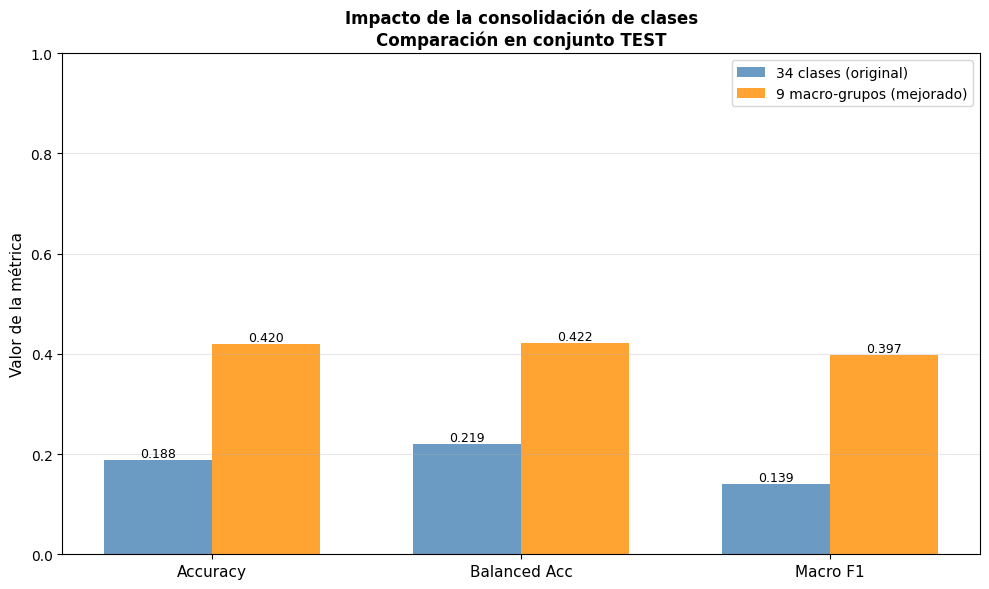

In [35]:
# ── Mostrar gráfica comparativa final ───────────────────────
labels  = ['Accuracy', 'Balanced Acc', 'Macro F1']
v34     = [test_acc,  test_bacc,  test_f1]
v9      = [test2_acc, test2_bacc, test2_f1]

x = np.arange(len(labels))
w = 0.35
fig_cmp, ax_cmp = plt.subplots(figsize=(10, 6))
bars1 = ax_cmp.bar(x - w/2, v34, w, label='34 clases (original)', color='steelblue', alpha=0.8)
bars2 = ax_cmp.bar(x + w/2, v9,  w, label='9 macro-grupos (mejorado)', color='darkorange', alpha=0.8)
ax_cmp.set_xticks(x)
ax_cmp.set_xticklabels(labels, fontsize=11)
ax_cmp.set_ylabel('Valor de la métrica', fontsize=11)
ax_cmp.set_title('Impacto de la consolidación de clases\nComparación en conjunto TEST', fontsize=12, fontweight='bold')
ax_cmp.legend(fontsize=10)
ax_cmp.set_ylim(0, 1)
ax_cmp.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax_cmp.annotate(f'{height:.3f}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax_cmp.annotate(f'{height:.3f}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Fase 8: Optimizacion de features y ajuste fino del modelo

El mejor modelo hasta ahora (CatBoost, 9 macro-grupos) alcanzo ~42 % de Balanced Accuracy.
Se aplican dos mejoras:

1. **Binning de edad adicional (`grupo_edad`)**: La edad continua ya aporta informacion, pero agregar el tramo epidemiologico como variable categorica extra permite al modelo aprender patrones discretos por etapa de vida (Neonatal, Infantil, Ninez, Adolescente, Adulto joven, Adulto, Adulto mayor) sin perder la señal continua.
2. **Ajuste fino de CatBoost**: Se aumentan las iteraciones (800), se reduce la tasa de aprendizaje (0.05) y se incrementa la profundidad (depth=8). El resto de features se conserva porque CatBoost maneja categorias de alta cardinalidad (como `municipio`) via target encoding interno.

In [40]:
# ── Fase 8 – Feature engineering: agregar grupo_edad sobre features v2 ──────

# 1. Bins epidemiologicos de edad (se agrega, no se reemplaza edad continua)
def asignar_grupo_edad(e):
    if pd.isna(e): return 'Desconocido'
    e = int(e)
    if e == 0:      return 'Neonatal'
    elif e <= 4:    return 'Infantil'
    elif e <= 14:   return 'Ninez'
    elif e <= 24:   return 'Adolescente'
    elif e <= 44:   return 'Adulto_joven'
    elif e <= 64:   return 'Adulto'
    else:           return 'Adulto_mayor'

# Partir de df_model2 (ya tiene area_geografica y lugar_ocurrencia)
df_model3 = df_model2.copy()
df_model3['grupo_edad'] = df_model3['edad'].apply(asignar_grupo_edad)
print('Distribucion grupo_edad:')
print(df_model3['grupo_edad'].value_counts())

# 2. Verificar si existe columna Etnia
etnia_col = resolve_column(df, ['Etnia', 'Etnidif', 'Etni'])
if etnia_col:
    df_model3['etnia'] = df[etnia_col].values
    print(f'\nEtnia detectada: {etnia_col} ({df[etnia_col].nunique()} categorias)')
else:
    print('\nEtnia no disponible en el dataset.')

# 3. Features v3: todos los de v2 + grupo_edad (municipio se conserva)
num_features3 = num_features  # ['edad', 'mes', 'dia', 'anio', 'es_fin_semana']
cat_features3 = cat_features2 + ['grupo_edad']  # agrega grupo_edad al conjunto v2
if etnia_col and 'etnia' in df_model3.columns:
    cat_features3 = cat_features3 + ['etnia']

print(f'\nFeatures numericas : {num_features3}')
print(f'Features categoricas: {cat_features3}')
print(f'Total features: {len(num_features3) + len(cat_features3)}')

# 4. Preprocesador v3
preprocessor3 = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), num_features3),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ]), cat_features3),
], remainder='drop')

# 5. Split estratificado (70/15/15) — mismas proporciones que v2
X3_train, X3_temp, y3_train, y3_temp = train_test_split(
    df_model3, y_macro2,
    test_size=0.30, random_state=RANDOM_STATE, stratify=y_macro2,
)
X3_valid, X3_test, y3_valid, y3_test = train_test_split(
    X3_temp, y3_temp,
    test_size=0.50, random_state=RANDOM_STATE, stratify=y3_temp,
)
print(f'\nSplit: Train={X3_train.shape[0]:,}  Valid={X3_valid.shape[0]:,}  Test={X3_test.shape[0]:,}')

# 6. Muestra estratificada para barrido
idx3, _ = train_test_split(
    range(len(X3_train)),
    train_size=SWEEP_SIZE, random_state=RANDOM_STATE, stratify=y3_train,
)
X3_sw = X3_train.iloc[idx3].reset_index(drop=True)
y3_sw = y3_train.iloc[idx3].reset_index(drop=True)
print(f'Muestra barrido: {X3_sw.shape}')

Distribucion grupo_edad:
grupo_edad
Adulto_mayor    407055
Adulto          188242
Adulto_joven    122238
Infantil         55943
Adolescente      55398
Ninez            39894
Desconocido       5175
Neonatal          4191
Name: count, dtype: int64

Etnia no disponible en el dataset.

Features numericas : ['edad', 'mes', 'dia', 'anio', 'es_fin_semana']
Features categoricas: ['sexo', 'departamento', 'municipio', 'estado_civil', 'escolaridad', 'ocupacion', 'area_geografica', 'lugar_ocurrencia', 'grupo_edad']
Total features: 14

Split: Train=614,695  Valid=131,720  Test=131,721
Muestra barrido: (60000, 14)


In [41]:
# ── CatBoost v3: features optimizados + hiperparametros ajustados ───────────

cb_pipe3 = Pipeline([
    ('prep', preprocessor3),
    ('clf', CatBoostClassifier(
        iterations=800,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=5,
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        verbose=0,
    )),
])

# Entrenamiento en muestra de barrido
t0 = time.time()
cb_pipe3.fit(X3_sw, y3_sw)
t_cb3_sw = time.time() - t0

y_pred_cb3_sw  = cb_pipe3.predict(X3_sw)
cb3_train_bacc = balanced_accuracy_score(y3_sw, y_pred_cb3_sw)

y_pred_cb3_valid = cb_pipe3.predict(X3_valid)
cb3_valid_acc    = accuracy_score(y3_valid, y_pred_cb3_valid)
cb3_valid_bacc   = balanced_accuracy_score(y3_valid, y_pred_cb3_valid)
cb3_gap          = cb3_train_bacc - cb3_valid_bacc

print('CatBoost v3 (features opt. + tuning fino) — muestra 60 000')
print(f'  Train Bal.Acc = {cb3_train_bacc:.4f}')
print(f'  Valid Acc     = {cb3_valid_acc:.4f}')
print(f'  Valid Bal.Acc = {cb3_valid_bacc:.4f}')
print(f'  Gap           = {cb3_gap:.4f}')
print(f'  Tiempo (s)    = {t_cb3_sw:.1f}')

# Reentrenar sobre conjunto completo de train
t0 = time.time()
cb_pipe3.fit(X3_train, y3_train)
t_cb3_full = time.time() - t0
print(f'\nEntrenamiento final CatBoost v3: {t_cb3_full:.1f} s  ({len(X3_train):,} registros)')

y_pred_cb3_valid_full = cb_pipe3.predict(X3_valid)
y_pred_cb3_test       = cb_pipe3.predict(X3_test)

test3_acc  = accuracy_score(y3_test, y_pred_cb3_test)
test3_bacc = balanced_accuracy_score(y3_test, y_pred_cb3_test)
test3_f1   = f1_score(y3_test, y_pred_cb3_test, average='macro', zero_division=0)

print(f'\nMetricas en TEST (features optimizados + CatBoost tuned):')
print(f'  Accuracy          : {test3_acc:.4f}')
print(f'  Balanced Accuracy : {test3_bacc:.4f}')
print(f'  Macro F1          : {test3_f1:.4f}')

print('\nReporte por clase:')
print(classification_report(y3_test, y_pred_cb3_test, zero_division=0))

CatBoost v3 (features opt. + tuning fino) — muestra 60 000
  Train Bal.Acc = 0.4884
  Valid Acc     = 0.4021
  Valid Bal.Acc = 0.4039
  Gap           = 0.0846
  Tiempo (s)    = 41.4

Entrenamiento final CatBoost v3: 257.0 s  (614,695 registros)

Metricas en TEST (features optimizados + CatBoost tuned):
  Accuracy          : 0.4207
  Balanced Accuracy : 0.4233
  Macro F1          : 0.3983

Reporte por clase:
                            precision    recall  f1-score   support

          Cardiovasculares       0.39      0.39      0.39     21800
           Causas_externas       0.74      0.80      0.77     17334
Digestivas_genitourinarias       0.27      0.23      0.25     15636
    Endocrinas_metabolicas       0.25      0.26      0.25     13769
 Infecciosas_respiratorias       0.49      0.28      0.36     19329
             Mal_definidas       0.53      0.50      0.52     19159
         Materno_perinatal       0.48      0.85      0.62      6716
                Neoplasias       0.28      0

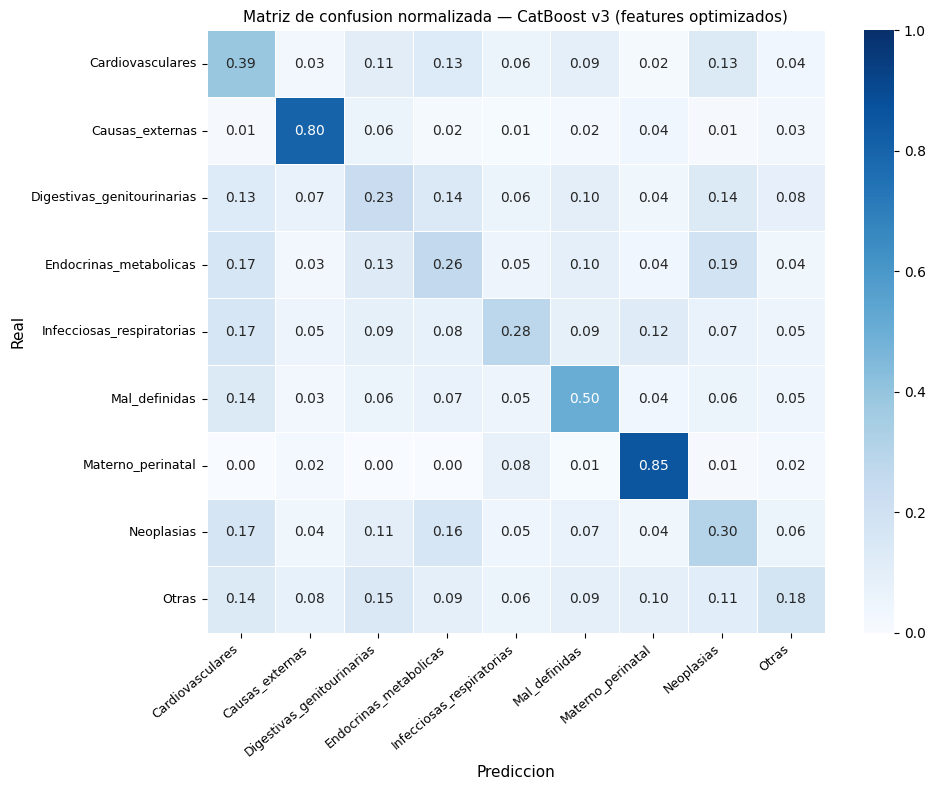

In [42]:
# ── Matriz de confusion normalizada — CatBoost v3 ───────────────────────────
classes3 = sorted(y3_test.unique())
cm3 = confusion_matrix(y3_test, y_pred_cb3_test, labels=classes3, normalize='true')

fig_cm3, ax_cm3 = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm3,
    xticklabels=classes3,
    yticklabels=classes3,
    cmap='Blues',
    vmin=0, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax_cm3,
)
ax_cm3.set_xlabel('Prediccion', fontsize=11)
ax_cm3.set_ylabel('Real', fontsize=11)
ax_cm3.set_title('Matriz de confusion normalizada — CatBoost v3 (features optimizados)', fontsize=11)
ax_cm3.set_xticklabels(ax_cm3.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax_cm3.set_yticklabels(ax_cm3.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

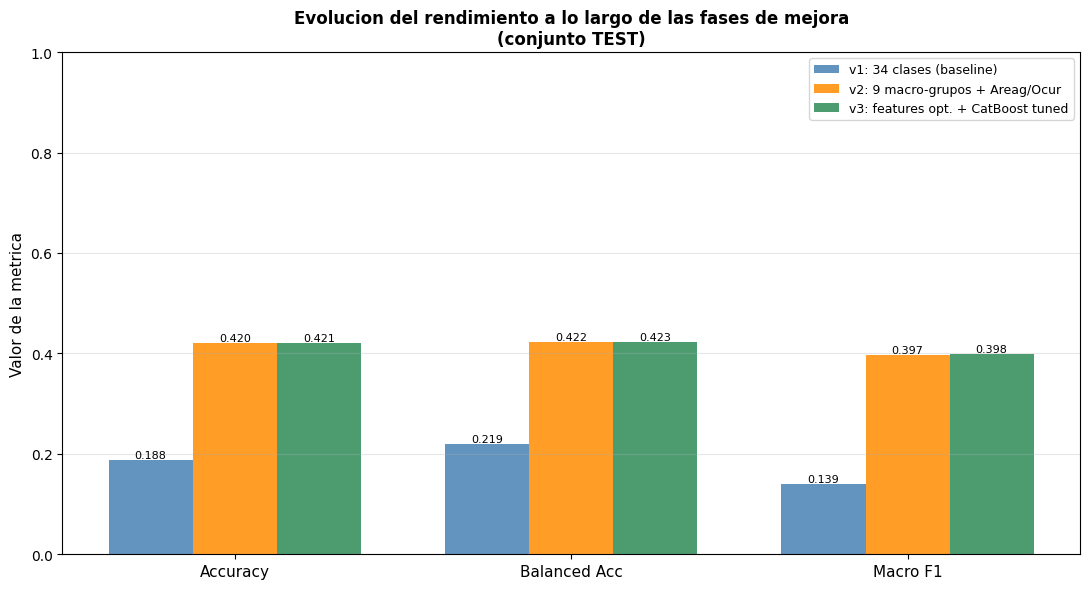


Resumen evolucion (TEST):
  v1 (34 clases)          Bal.Acc=0.2192
  v2 (9 macro-grupos)     Bal.Acc=0.4222  (+92.6%)
  v3 (features opt.)      Bal.Acc=0.4233  (+0.3%)


In [43]:
# ── Evolucion completa: 34 clases → 9 macro-grupos → features optimizados ────
labels_ev = ['Accuracy', 'Balanced Acc', 'Macro F1']
v_34      = [test_acc,   test_bacc,   test_f1]
v_9macro  = [test2_acc,  test2_bacc,  test2_f1]
v_optim   = [test3_acc,  test3_bacc,  test3_f1]

x = np.arange(len(labels_ev))
w = 0.25
fig_ev, ax_ev = plt.subplots(figsize=(11, 6))
bars_v1 = ax_ev.bar(x - w, v_34,     w, label='v1: 34 clases (baseline)',           color='steelblue',  alpha=0.85)
bars_v2 = ax_ev.bar(x,     v_9macro,  w, label='v2: 9 macro-grupos + Areag/Ocur',    color='darkorange', alpha=0.85)
bars_v3 = ax_ev.bar(x + w, v_optim,   w, label='v3: features opt. + CatBoost tuned', color='seagreen',   alpha=0.85)

ax_ev.set_xticks(x)
ax_ev.set_xticklabels(labels_ev, fontsize=11)
ax_ev.set_ylabel('Valor de la metrica', fontsize=11)
ax_ev.set_title('Evolucion del rendimiento a lo largo de las fases de mejora\n(conjunto TEST)', fontsize=12, fontweight='bold')
ax_ev.legend(fontsize=9)
ax_ev.set_ylim(0, 1)
ax_ev.grid(axis='y', alpha=0.3)

for bar in list(bars_v1) + list(bars_v2) + list(bars_v3):
    h = bar.get_height()
    ax_ev.annotate(f'{h:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, h),
                   ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print('\nResumen evolucion (TEST):')
print(f'  v1 (34 clases)          Bal.Acc={test_bacc:.4f}')
print(f'  v2 (9 macro-grupos)     Bal.Acc={test2_bacc:.4f}  (+{(test2_bacc-test_bacc)/test_bacc*100:.1f}%)')
print(f'  v3 (features opt.)      Bal.Acc={test3_bacc:.4f}  (+{(test3_bacc-test2_bacc)/test2_bacc*100:.1f}%)')